# Notebook 1: Energy Attribution to Callgraph Functions

This notebook demonstrates our method for attributing GPU energy consumption to individual
functions in the MPI call graph. For each benchmark discovered under `app-traces/`, we:

1. Exclusively attribute per-device energy samples to the deepest active call at each time point
2. Visualize the call-tree structure as a **flame chart** with power overlay
3. Show a **per-rank energy heatmap** highlighting load imbalance across MPI ranks
4. Compare **library energy breakdown** across all available benchmarks


In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.collections import PatchCollection
from pathlib import Path
from scipy.stats import gaussian_kde

from ampere import Ensemble, MetricConfig, MetricType, connect, set_backend, DataFrame

set_backend('pandas')
connect(server="localhost", port=5555)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 9.5,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
    'figure.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.0,
})
BG = '#fafafa'

ENERGY_DEVICES = [f"A2rocm_smi:::energy_count:device={d}" for d in [0, 2, 4, 6]]

# Library classification colors
PALETTE = {
    'rocBLAS':     '#2d6a4f',
    'rocSOLVER':   '#e07a3a',
    'HIP Runtime': '#9b5de5',
    'OpenMP':      '#f15bb5',
    'MPI':         '#adb5bd',
    'Other':       '#6c757d',
}
LIB_ORDER = ['rocBLAS', 'rocSOLVER', 'HIP Runtime', 'OpenMP', 'MPI', 'Other']


    _         _                   _       
   / \   _ __| | _____  _   _  __| | __ _ 
  / _ \ | '__| |/ / _ \| | | |/ _` |/ _` |
 / ___ \| |  |   < (_) | |_| | (_| | (_| |
/_/   \_\_|  |_|\_\___/ \__,_|\__,_|\__,_|
                                          
Client Version: 2026.02.02+40.gec39a6ec8Pandas backend active — skipping Arkouda connection.


## 1. Data Discovery

Scan `app-traces/` and find every benchmark with CSV data. New benchmarks placed here will be picked up automatically.

In [2]:
APP_TRACES_ROOT = Path("./new-app-traces")

def discover_benchmarks(root: Path) -> dict:
    """Return {benchmark_name: Path(trial_dir)} for every trial with CSV data."""
    found = {}
    for bench in sorted(root.iterdir()):
        if not bench.is_dir():
            continue
        for trial in sorted(bench.iterdir()):
            if not trial.is_dir():
                continue
            csvs = (list(trial.glob("MPI Rank*_Master_thread_callgraph.csv")) +
                    list(trial.glob("MPI Rank*_callgraph.csv")))
            if csvs:
                found[bench.name] = trial
                break
        else:
            print(f"  [no data yet] {bench.name}")
    print(f"\nDiscovered {len(found)} benchmark(s): {list(found.keys())}")
    return found

BENCHMARKS = discover_benchmarks(APP_TRACES_ROOT)



Discovered 5 benchmark(s): ['HPG-MxP-Full', 'HPL', 'HPL-MxP', 'LSMS', 'QMCPACK']


## 2. Helper Functions

In [3]:
# In-memory caches that survive across cells. Re-running this helpers cell
# clears them; everything else just reuses the cached results.
_POWER_CACHE: dict = {}
_FLAME_CACHE: dict = {}
_ATTR_CACHE:  dict = {}
_CG_CACHE:    dict = {}


def get_callgraph(cg_path: Path) -> pd.DataFrame:
    """Cached: read the rank-0 master callgraph CSV exactly once per path.
    Includes a precomputed Duration column. Callers MUST .copy() before
    mutating — the returned DataFrame is the shared cache entry."""
    key = str(cg_path)
    if key not in _CG_CACHE:
        df = pd.read_csv(cg_path, usecols=['Depth', 'Name', 'Start Time', 'End Time'])
        df['Duration'] = df['End Time'] - df['Start Time']
        _CG_CACHE[key] = df
    return _CG_CACHE[key]


def classify(name: str) -> str:
    n = name.lower().split('(')[0].strip()
    if n.startswith('mpi_'):         return 'MPI'
    if n.startswith('rocsolver'):    return 'rocSOLVER'
    if n.startswith('rocblas'):      return 'rocBLAS'
    if n.startswith('hip') or 'devicemalloc' in n or 'hostmalloc' in n:
        return 'HIP Runtime'
    # if n.startswith('hpl_') or n.startswith('hplmxp'):
    #     return 'HPL'
    if '!$omp' in n:
        return 'OpenMP'
    return 'Other'

def short_name(name: str) -> str:
    p = name.find('(')
    base = name[:p] if p != -1 else name
    a = base.find('<')
    return (base[:a] if a != -1 else base).strip()

def make_node_ranks(trial_path: Path) -> dict | None:
    """Infer node_ranks dict from CSV filenames in trial_path."""
    ranks = set()
    for f in trial_path.iterdir():
        if not f.is_file(): continue
        m = re.match(r"(MPI Rank \d+)_", f.name)
        if m: ranks.add(m.group(1))
    if ranks:
        return {"Node0": sorted(ranks, key=lambda s: int(s.split()[-1]))}
    if any(f.name.startswith("Process_") for f in trial_path.iterdir() if f.is_file()):
        return {"Node0": ["Process"]}
    return None

def mpi_topology_resolver(metric_name, ranks):
    mapping = {'device=4': ('MPI Rank 3'),
               'device=2': ('MPI Rank 2'),
               'device=6': ('MPI Rank 1'),
               'device=0': ('MPI Rank 0')}
    for key, targets in mapping.items():
        if key in metric_name:
            return [r for r in ranks if r.name in targets]
    return ranks


# Score-P metrics config used by every attribution call in the notebook.
configs = {
    re.compile(r".*energy_count.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}


def _compute_combined_power(metrics_path: Path):
    """Differentiate the four energy counters and sum → combined GPU power (W)."""
    dm = pd.read_csv(metrics_path)
    series = []
    for dev in [0, 2, 4, 6]:
        sub = dm[dm['Metric Name'] == f'A2rocm_smi:::energy_count:device={dev}'].sort_values('Time')
        if len(sub) < 2: continue
        t  = sub['Time'].values
        e  = sub['Value'].values * 1e-6   # µJ → J
        dt = np.diff(t); de = np.diff(e)
        p  = np.where((dt > 0) & (de >= 0), de / dt, 0.0)
        series.append((t[1:], p))
    if not series:
        return None, None
    L     = min(len(pt) for pt, _ in series)
    t_ref = series[0][0][:L]
    p_ref = sum(np.interp(t_ref, pt, pv) for pt, pv in series)
    return t_ref, p_ref


def get_combined_power(metrics_path: Path):
    """Cached version of `_compute_combined_power`. First call differentiates;
    subsequent calls for the same path reuse the result."""
    key = str(metrics_path)
    if key not in _POWER_CACHE:
        _POWER_CACHE[key] = _compute_combined_power(metrics_path)
    return _POWER_CACHE[key]


compute_combined_power = get_combined_power
load_power_series      = get_combined_power


def get_attribution(trial_path: Path, *, verbose: bool = True) -> pd.DataFrame | None:
    """Cached: run Ensemble + 4× attribute() once per trial, concatenate the
    per-device results, and tag with ShortName/Library. Reused by both the
    Fig 2 heatmap and the Fig 3/4 library breakdown so attribution is paid for
    only once per benchmark even if those cells are re-run."""
    key = str(trial_path)
    if key in _ATTR_CACHE:
        return _ATTR_CACHE[key]

    node_ranks = make_node_ranks(trial_path)
    if not node_ranks:
        _ATTR_CACHE[key] = None
        return None

    if verbose:
        print(f"  [attribute] {trial_path.name} (one-time, will be cached)")
    ens = Ensemble.from_trace_paths([str(trial_path)], node_ranks, configs)
    parts = []
    for metric in ENERGY_DEVICES:
        try:
            df = ens.attribute(metric, topology_resolver=mpi_topology_resolver,
                               strategy='exclusive').to_pandas()
            if len(df) > 0:
                parts.append(df)
        except Exception:
            pass
    if not parts:
        _ATTR_CACHE[key] = None
        return None
    attr = pd.concat(parts, ignore_index=True)
    attr['ShortName'] = attr['Name'].apply(short_name)
    attr['Library']   = attr['Name'].apply(classify)
    _ATTR_CACHE[key] = attr
    return attr


## Figure 1: Energy Flame Chart

Call-tree timeline for the first available benchmark (rank 0).  
Bar color = library family; bars at each depth row represent individual function calls.  
The power trace above shows the raw GPU power consumption over the same time window.

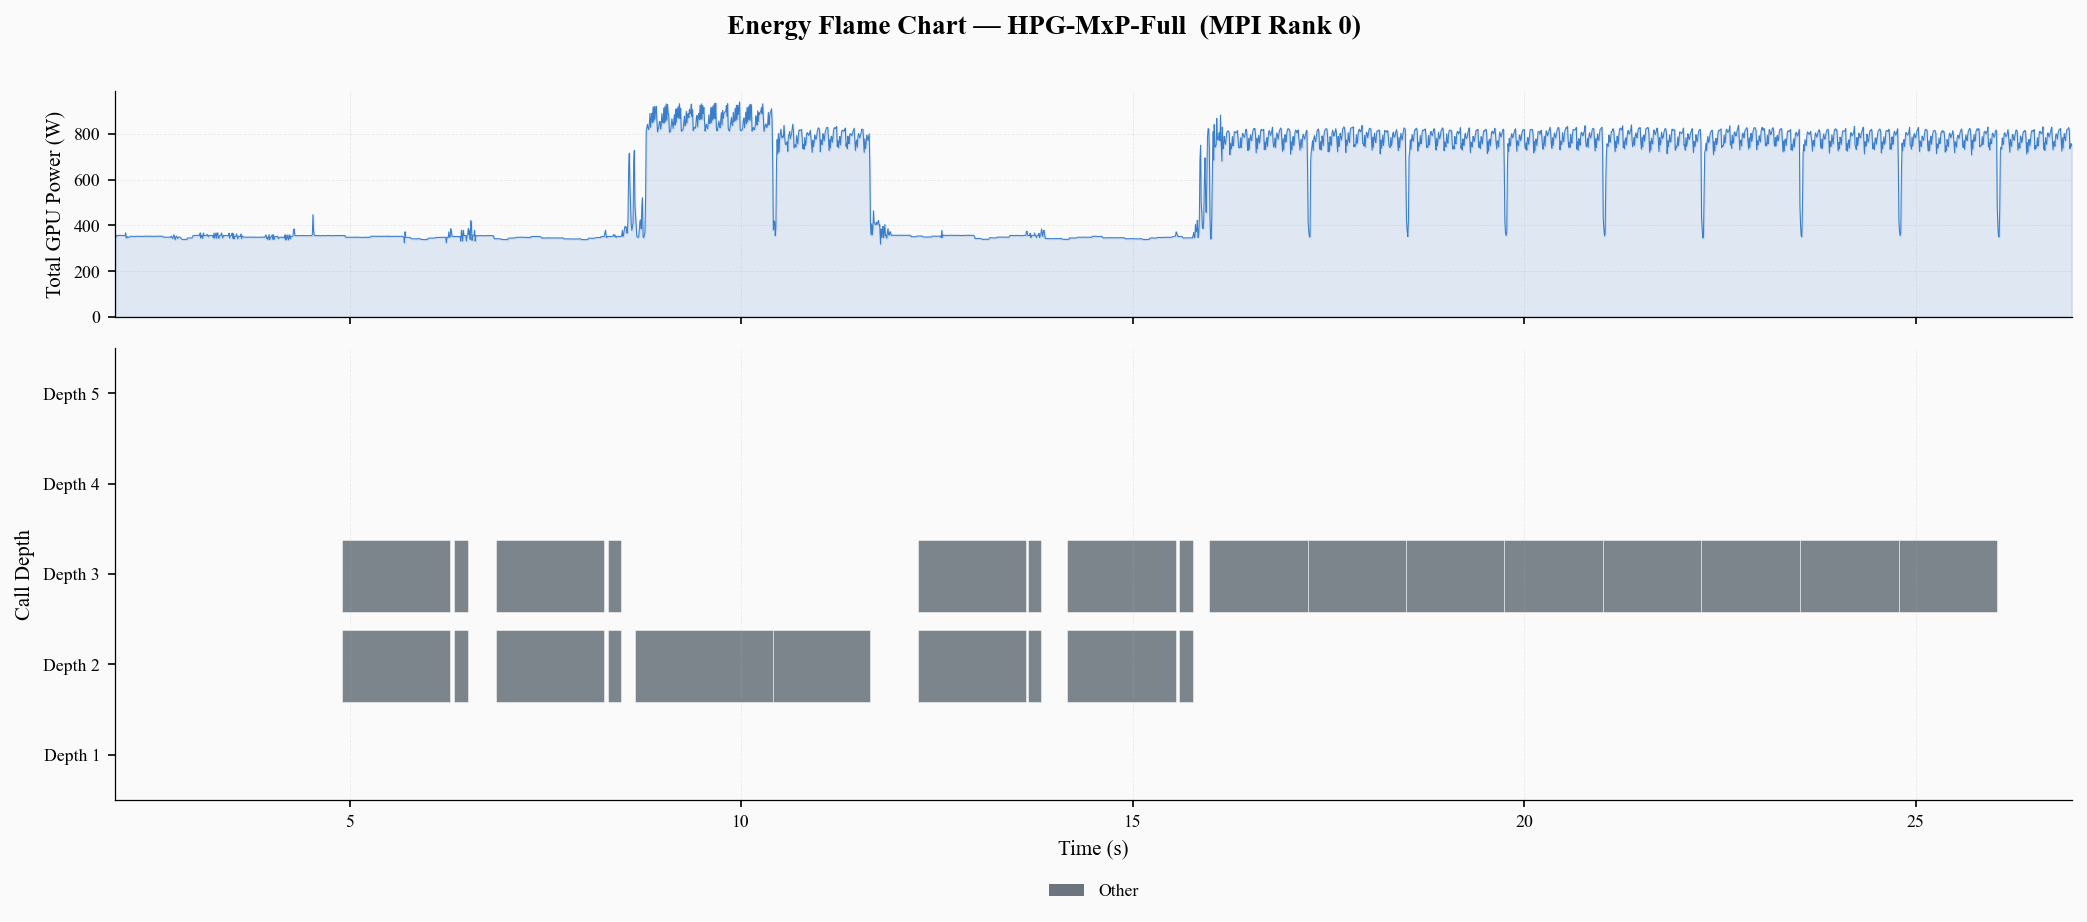

  Plotted 26 call bars across depths 1–5


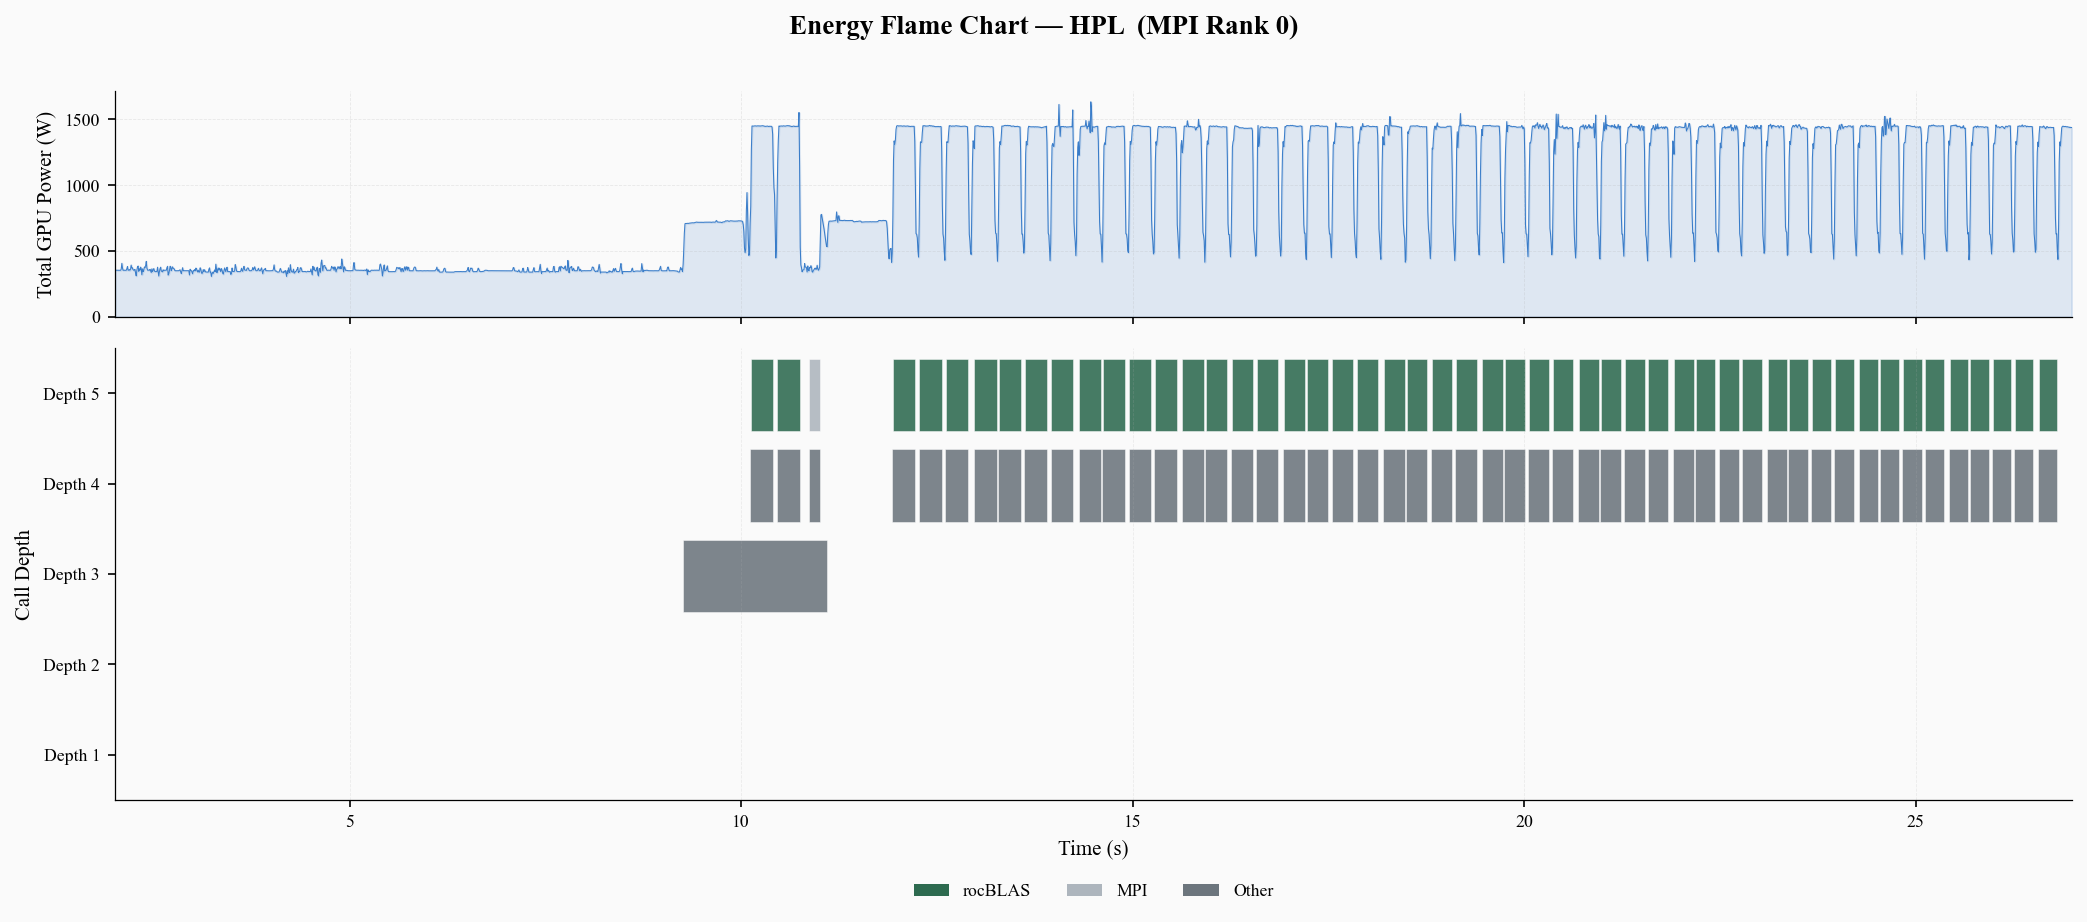

  Plotted 103 call bars across depths 1–5


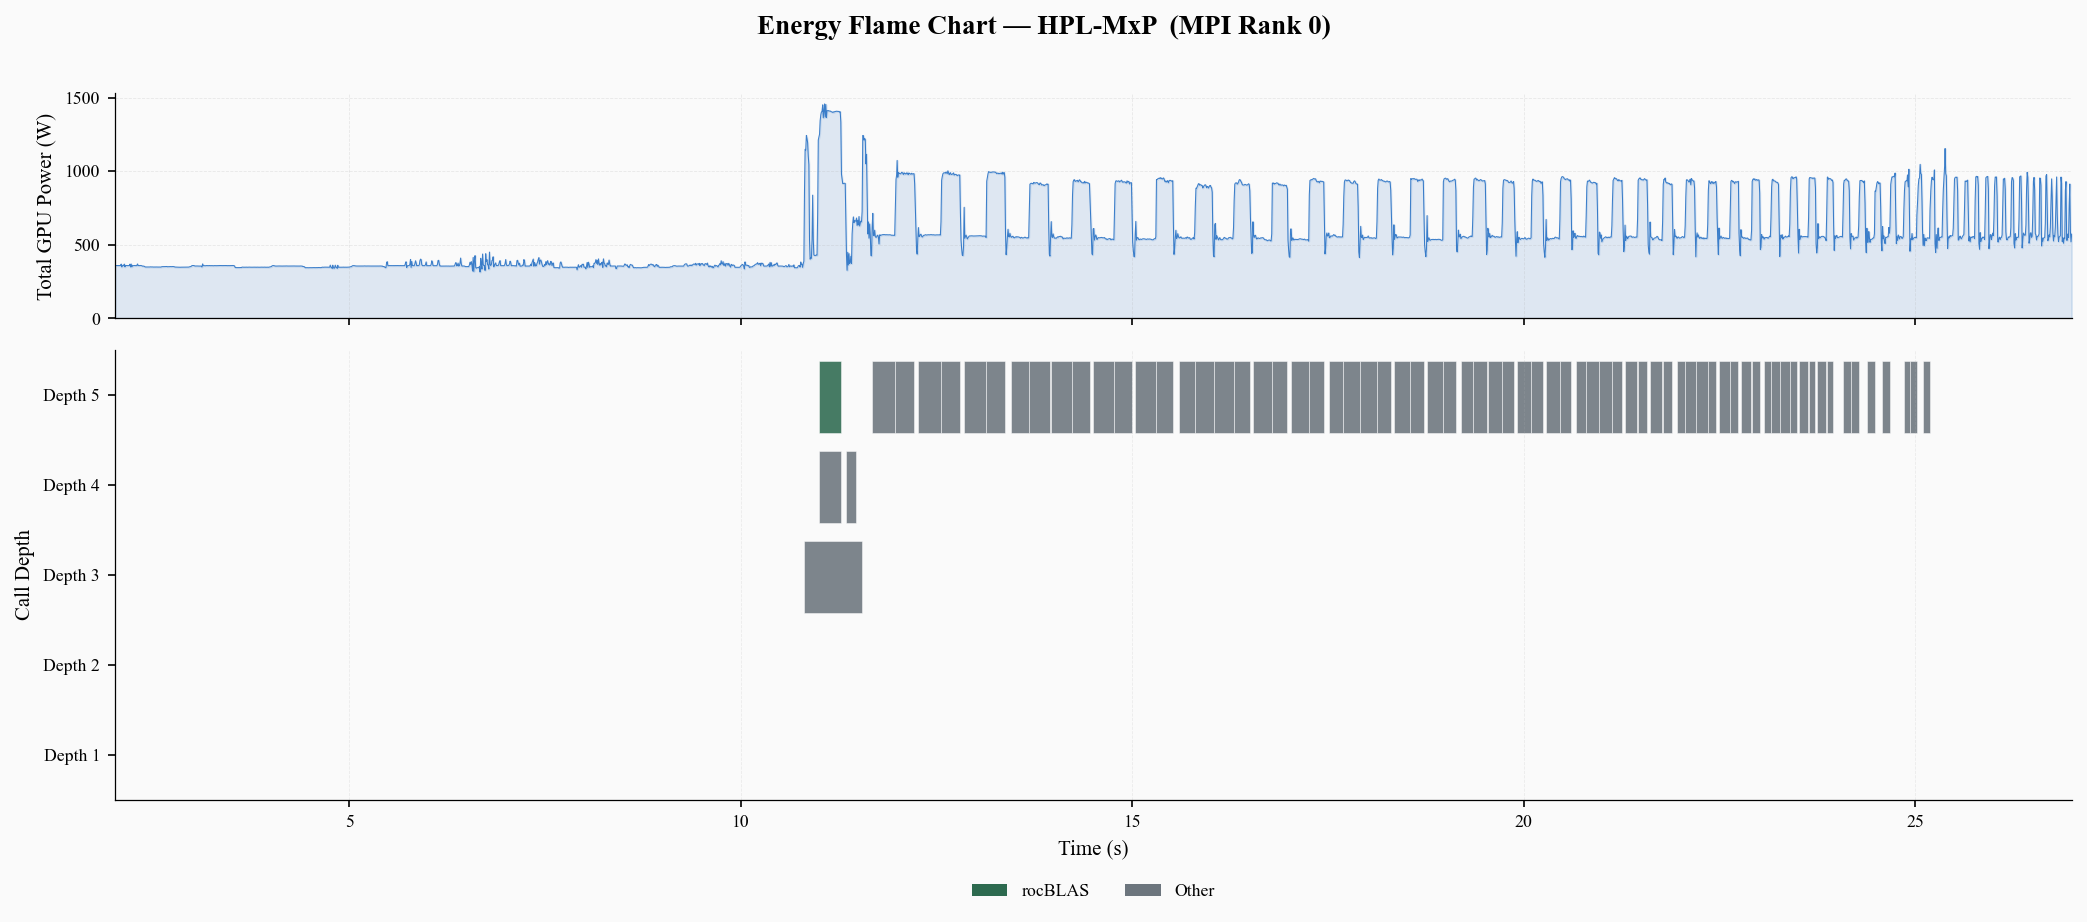

  Plotted 73 call bars across depths 1–5


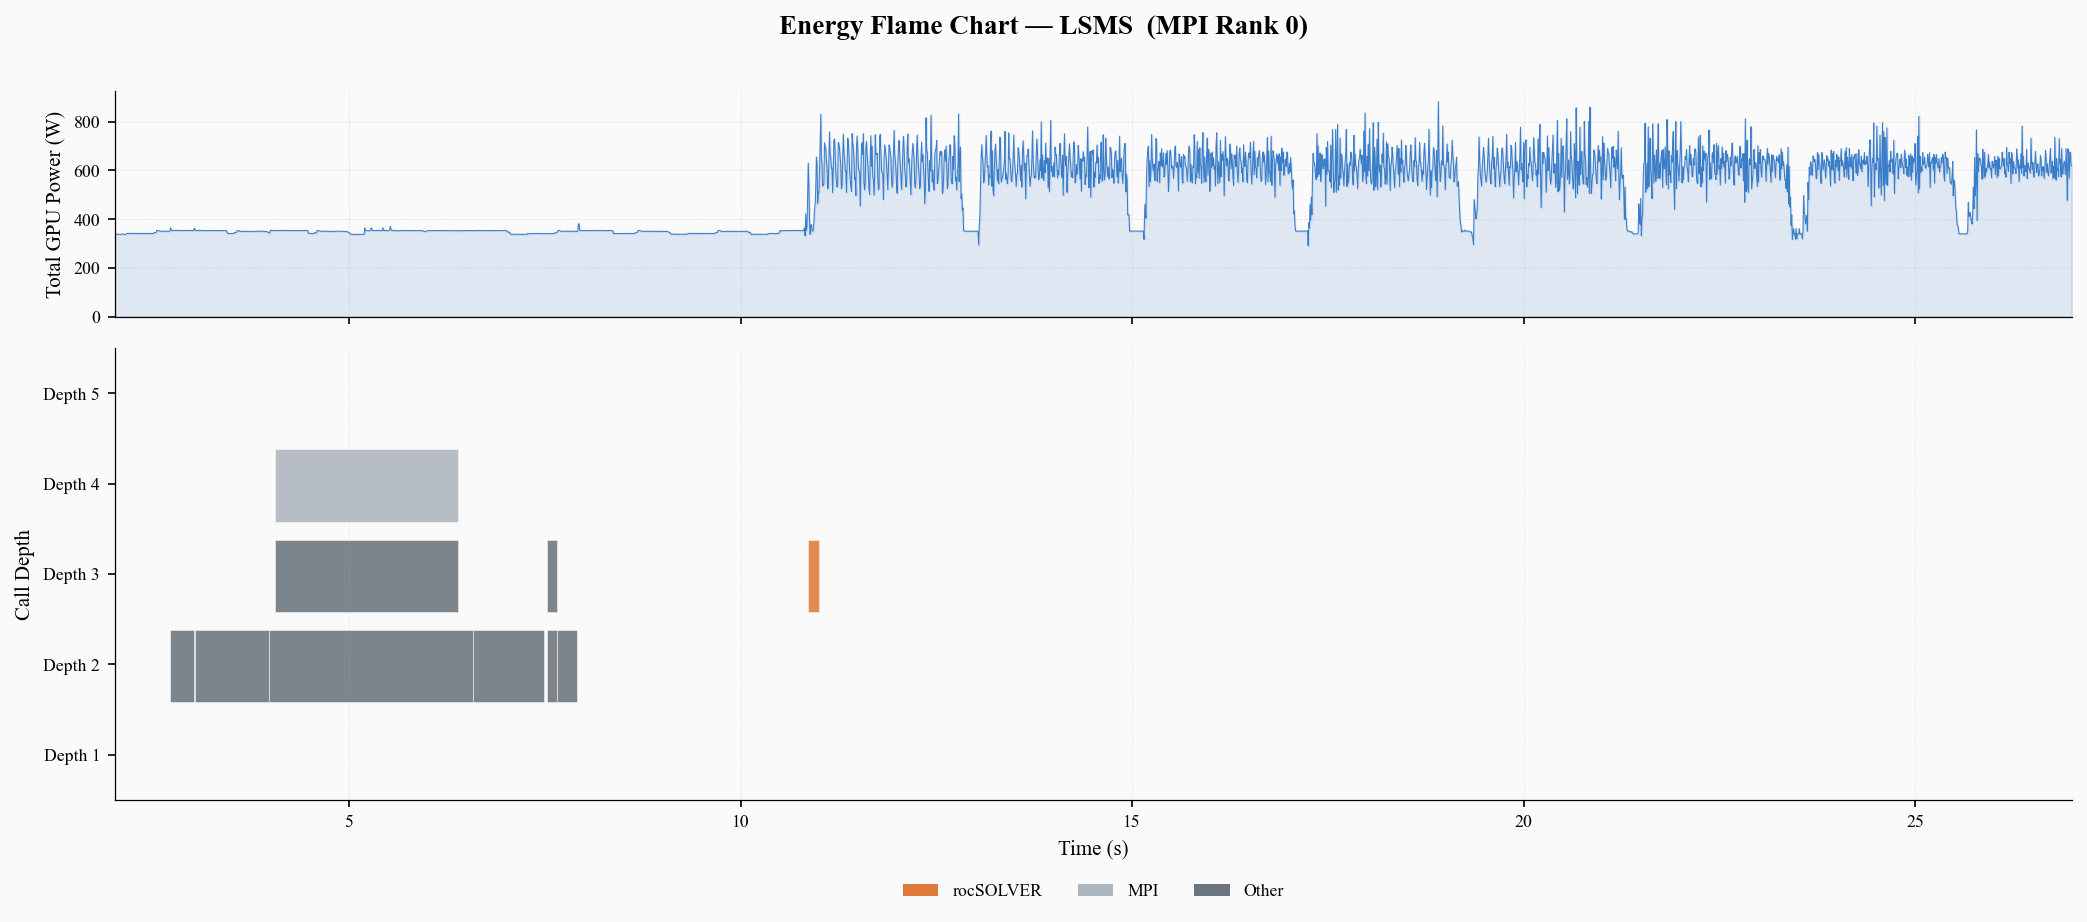

  Plotted 10 call bars across depths 1–5


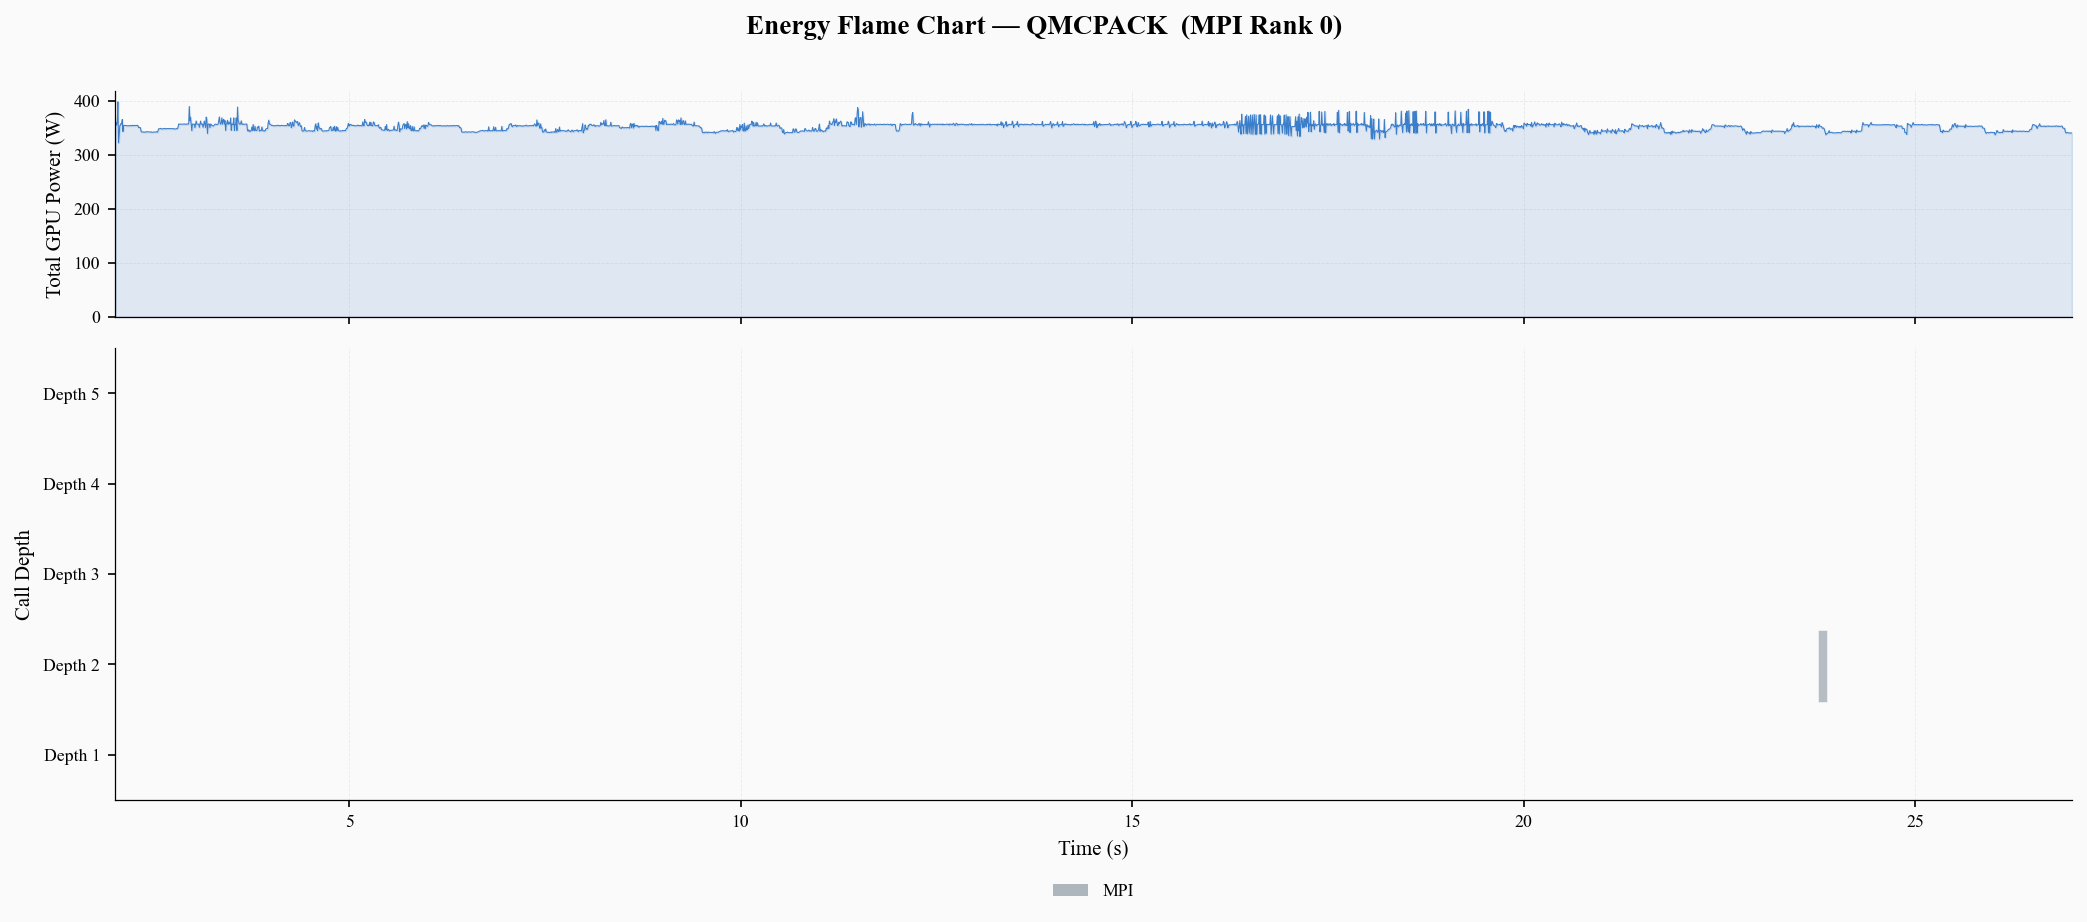

  Plotted 1 call bars across depths 1–5


In [4]:
def draw_flame_chart(bench_name: str, trial_path: Path,
                     rank_id: int = 0,
                     max_depth: int = 5,
                     min_dur_s: float = 0.08,
                     t_window: tuple | None = None,
                     save_prefix: str = "fig1"):
    cg_path = trial_path / f"MPI Rank {rank_id}_Master_thread_callgraph.csv"
    m_path  = trial_path / f"MPI Rank {rank_id}_metrics.csv"
    if not cg_path.exists() or not m_path.exists():
        print(f"  [skip] {bench_name}: no files for rank {rank_id}")
        return

    # Cached callgraph (incl. Duration). DO NOT mutate — slice-then-copy below.
    df_raw = get_callgraph(cg_path)
    if df_raw.empty:
        print(f"  [skip] {bench_name}: empty callgraph CSV")
        return

    if t_window is None:
        trace_start = df_raw['Start Time'].min()
        trace_end   = df_raw['End Time'].max()
        t0 = trace_start + 2.0
        t1 = min(trace_end, t0 + 25.0)
        t_window = (t0, t1)

    df = df_raw[(df_raw['Depth'] <= max_depth) &
                (df_raw['Duration'] >= min_dur_s)].copy()
    df['Library'] = df['Name'].apply(classify)
    df = df[(df['Start Time'] >= t_window[0]) &
            (df['End Time']   <= t_window[1])].copy()

    if df.empty:
        print(f"  [skip] {bench_name}: no calls survive filters "
              f"(max_depth={max_depth}, min_dur_s={min_dur_s}, "
              f"t_window=({t_window[0]:.2f}, {t_window[1]:.2f})). "
              f"Trace spans [{df_raw['Start Time'].min():.2f}, "
              f"{df_raw['End Time'].max():.2f}].")
        return

    power_t, power_v = get_combined_power(m_path)
    if power_t is not None:
        mask    = (power_t >= t_window[0]) & (power_t <= t_window[1])
        power_t = power_t[mask]
        power_v = power_v[mask]

    fig, (ax_p, ax_f) = plt.subplots(2, 1, figsize=(14, 6), facecolor=BG,
                                      gridspec_kw={'height_ratios': [1, 2]},
                                      sharex=True)
    ax_p.set_facecolor(BG)
    ax_f.set_facecolor(BG)

    if power_t is not None and len(power_t) > 0:
        ax_p.plot(power_t, power_v, lw=0.5, color='#1565C0', alpha=0.8)
        ax_p.fill_between(power_t, power_v, alpha=0.12, color='#1565C0')
        ax_p.set_ylabel('Total GPU Power (W)')
        ax_p.set_ylim(0)
        ax_p.grid(alpha=0.25, linestyle='--')

    present_libs = []
    for _, row in df.iterrows():
        lib   = row['Library']
        color = PALETTE.get(lib, '#6c757d')
        rect  = mpatches.FancyBboxPatch(
            (row['Start Time'], row['Depth'] - 0.42),
            row['Duration'], 0.80,
            boxstyle="square,pad=0",
            facecolor=color, edgecolor='white', linewidth=0.25, alpha=0.88
        )
        ax_f.add_patch(rect)
        if lib not in present_libs:
            present_libs.append(lib)

    ax_f.set_xlim(*t_window)
    ax_f.set_ylim(0.5, max_depth + 0.5)
    ax_f.set_yticks(range(1, max_depth + 1))
    ax_f.set_yticklabels([f'Depth {d}' for d in range(1, max_depth + 1)])
    ax_f.set_xlabel('Time (s)')
    ax_f.set_ylabel('Call Depth')
    ax_f.grid(axis='x', alpha=0.2, linestyle='--')

    handles = [mpatches.Patch(facecolor=PALETTE[lib], label=lib)
               for lib in LIB_ORDER if lib in present_libs]
    if handles:
        ax_f.legend(handles=handles, frameon=False, ncol=len(handles),
                    loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=8.5)

    fig.suptitle(f'Energy Flame Chart — {bench_name}  (MPI Rank {rank_id})',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    fig.savefig(f'{save_prefix}_{bench_name}_flame.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()
    print(f"  Plotted {len(df):,} call bars across depths 1–{max_depth}")

for bench_name, trial_path in BENCHMARKS.items():
    draw_flame_chart(bench_name, trial_path)


## Figure 2: Exclusive Energy Heatmap

Rows = functions (sorted by total energy), columns = MPI ranks. Cell value = total exclusive energy (J) attributed to that function on that rank. Background color encodes magnitude — load imbalance shows up as hot/cold columns.

  [attribute] HPG-MxP-trial-1 (one-time, will be cached)


Loading Runs: 100%|██████████| 1/1 [00:08<00:00,  8.63s/it]


Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:03<00:00,  3.03s/it]


Attributing 'A2rocm_smi:::energy_count:device=2' (pandas backend)...


100%|██████████| 1/1 [00:03<00:00,  3.28s/it]


Attributing 'A2rocm_smi:::energy_count:device=4' (pandas backend)...


100%|██████████| 1/1 [00:03<00:00,  3.95s/it]


Attributing 'A2rocm_smi:::energy_count:device=6' (pandas backend)...


100%|██████████| 1/1 [00:03<00:00,  3.11s/it]


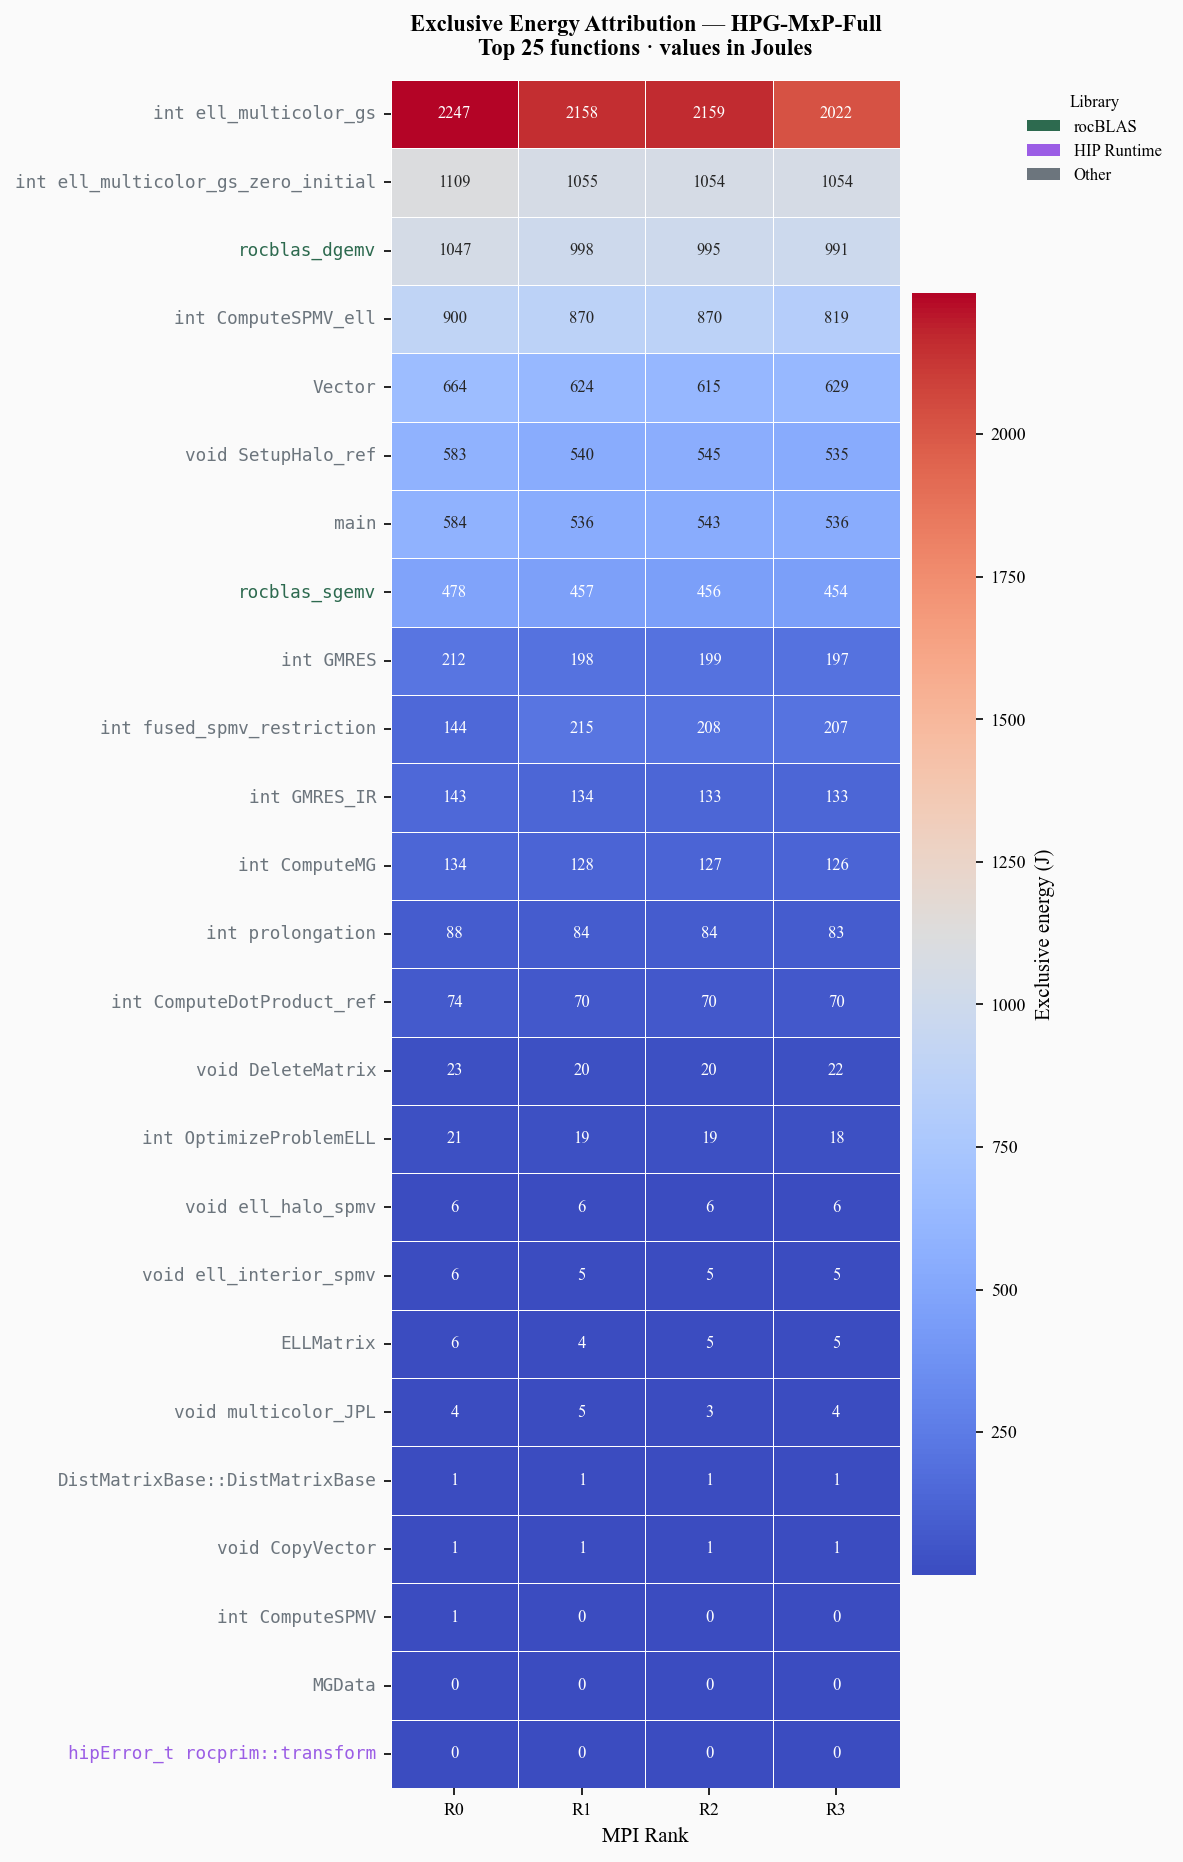

  [attribute] rocHPL-trial-1 (one-time, will be cached)


Loading Runs: 100%|██████████| 1/1 [00:03<00:00,  3.88s/it]


Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00,  3.17it/s]


Attributing 'A2rocm_smi:::energy_count:device=2' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00,  3.22it/s]


Attributing 'A2rocm_smi:::energy_count:device=4' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00,  3.16it/s]


Attributing 'A2rocm_smi:::energy_count:device=6' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00,  3.04it/s]


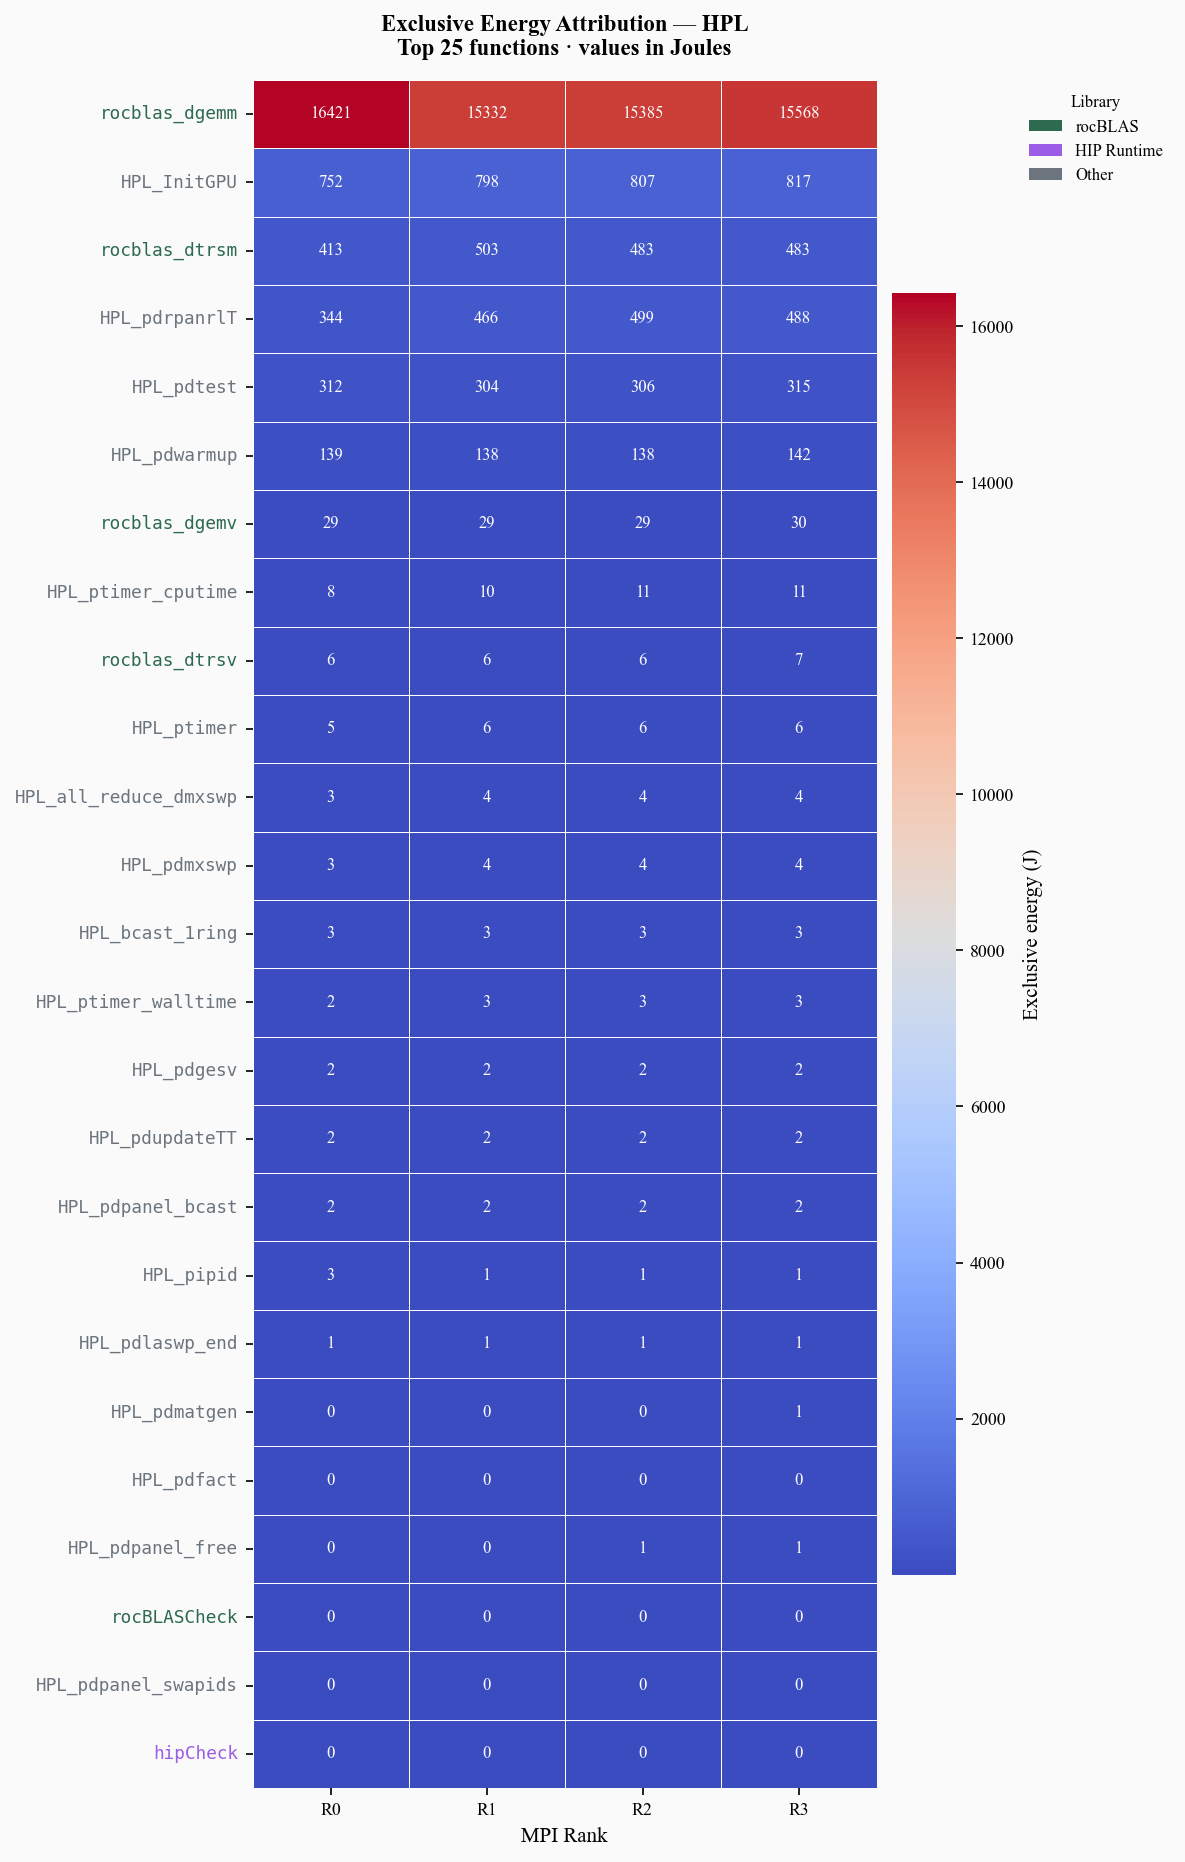

  [attribute] rocHPL-MxP-trial-1 (one-time, will be cached)


Loading Runs: 100%|██████████| 1/1 [00:00<00:00,  2.98it/s]


Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 33.69it/s]


Attributing 'A2rocm_smi:::energy_count:device=2' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 32.63it/s]


Attributing 'A2rocm_smi:::energy_count:device=4' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 33.98it/s]


Attributing 'A2rocm_smi:::energy_count:device=6' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 33.09it/s]


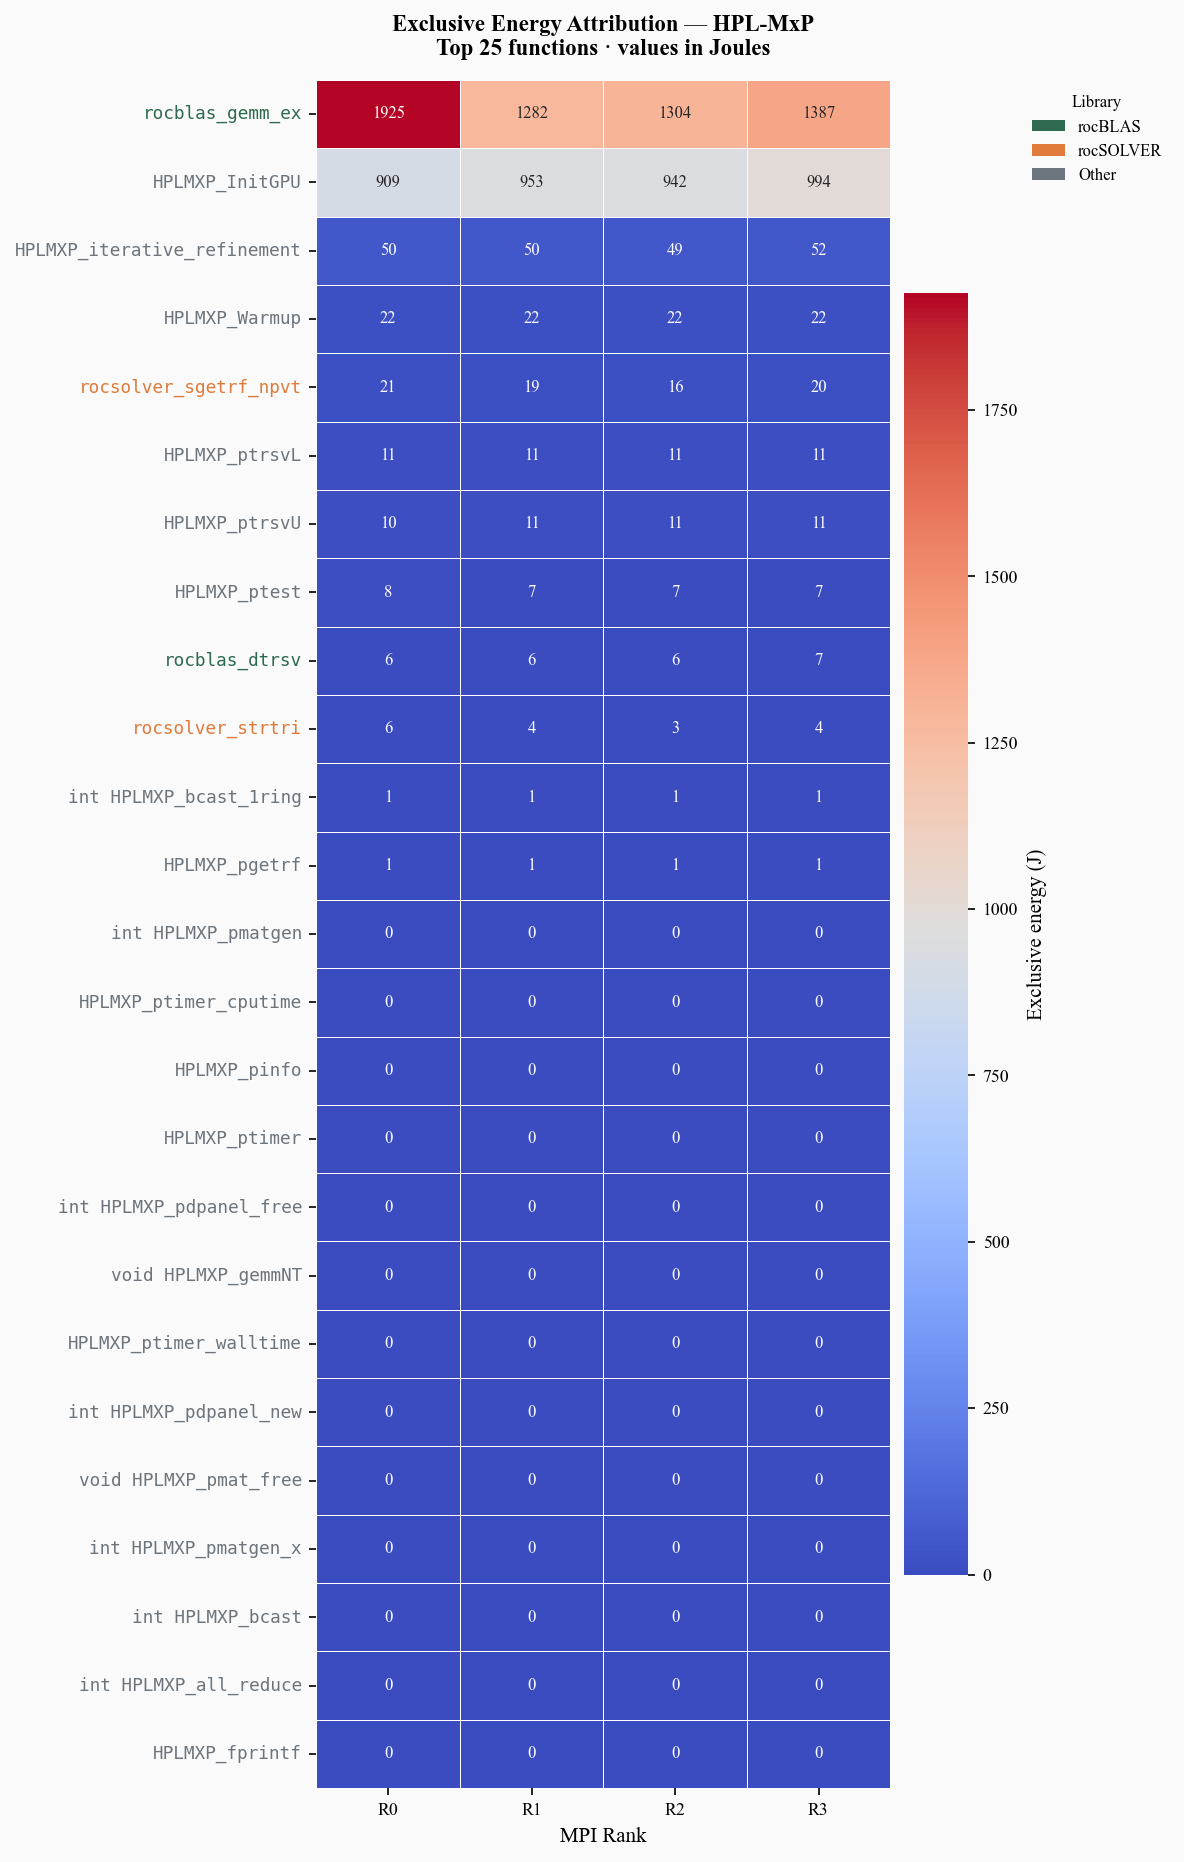

  [attribute] LSMS-trial-1 (one-time, will be cached)


Loading Runs: 100%|██████████| 1/1 [00:00<00:00, 13.43it/s]


Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 154.94it/s]


Attributing 'A2rocm_smi:::energy_count:device=2' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 247.95it/s]


Attributing 'A2rocm_smi:::energy_count:device=4' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 204.71it/s]


Attributing 'A2rocm_smi:::energy_count:device=6' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 208.41it/s]


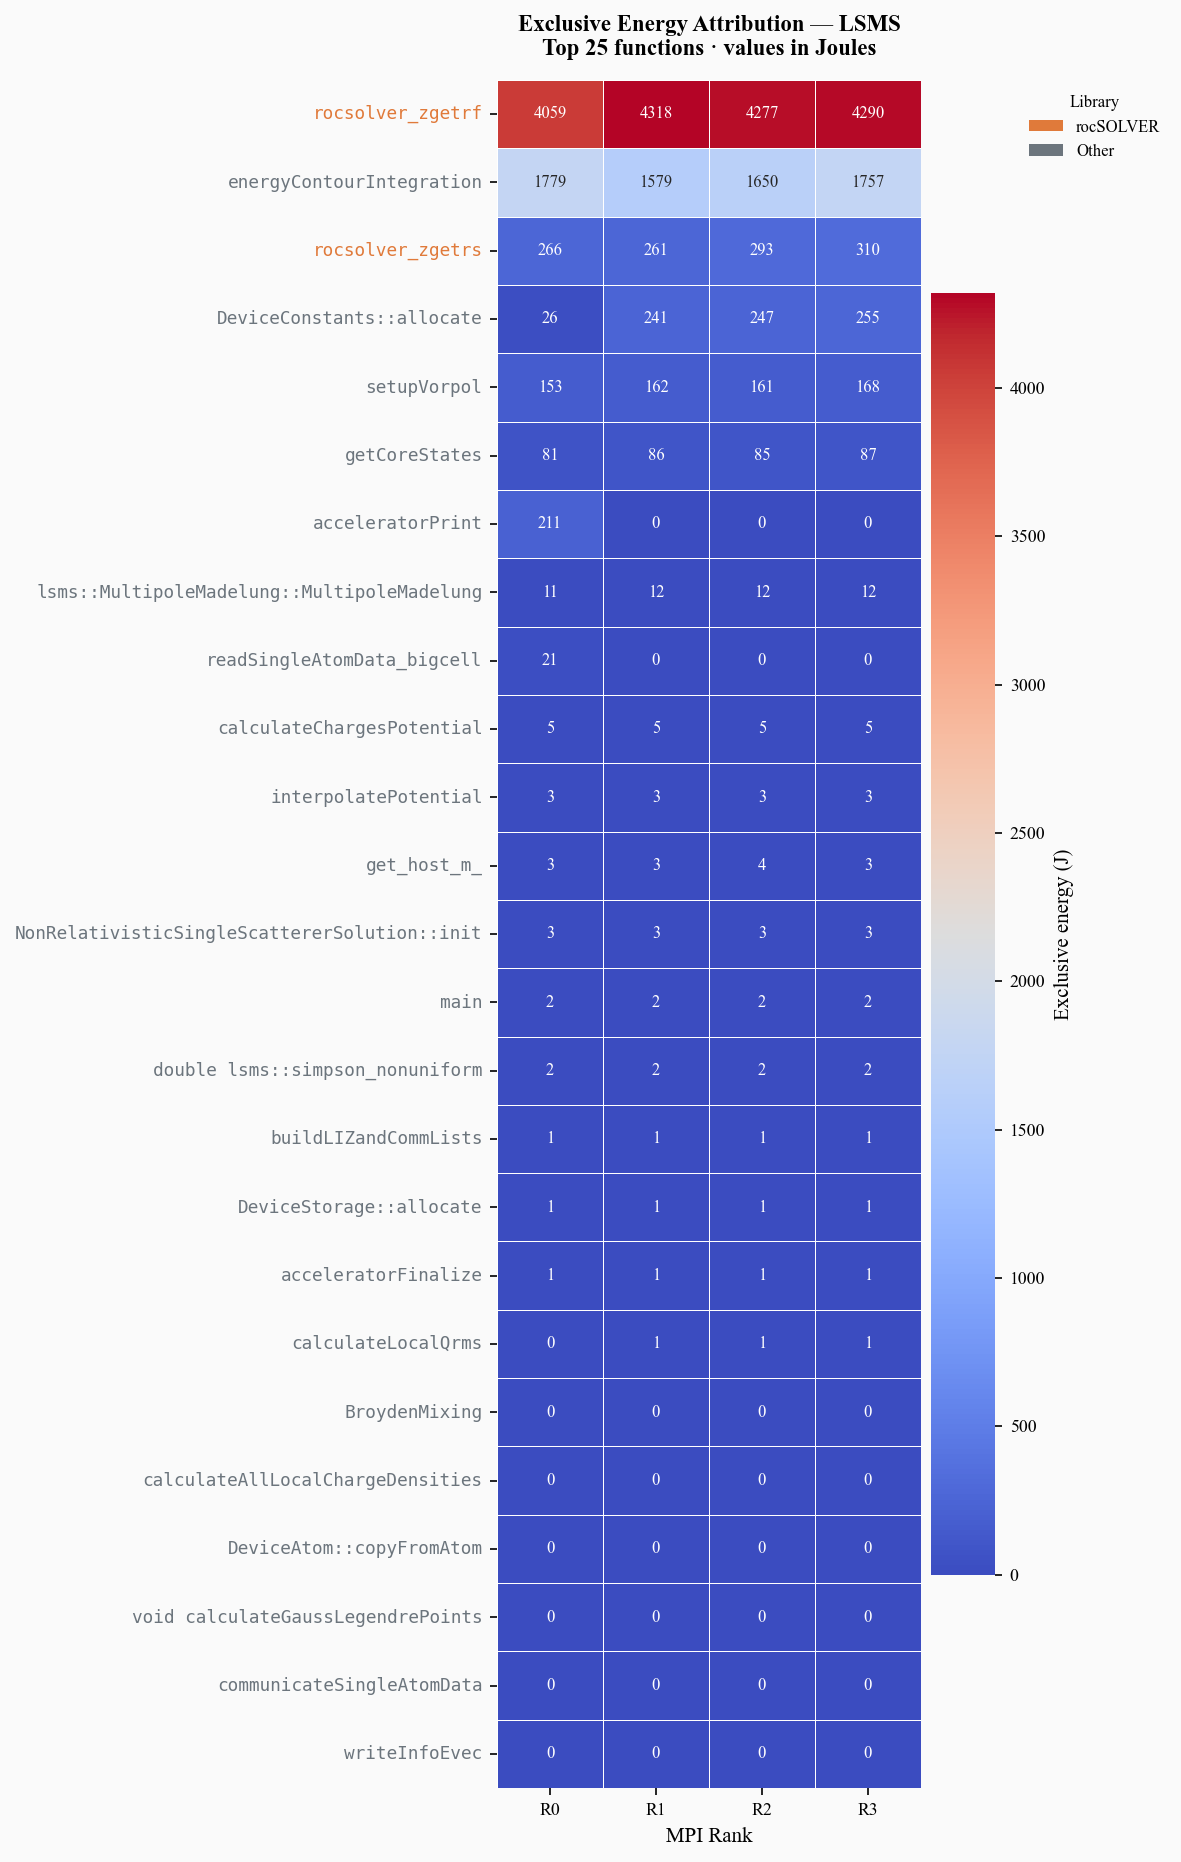

  [attribute] qmcpack-trial-1 (one-time, will be cached)


Loading Runs: 100%|██████████| 1/1 [00:20<00:00, 20.49s/it]


Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:03<00:00,  3.55s/it]


Attributing 'A2rocm_smi:::energy_count:device=2' (pandas backend)...


100%|██████████| 1/1 [00:03<00:00,  3.78s/it]


Attributing 'A2rocm_smi:::energy_count:device=4' (pandas backend)...


100%|██████████| 1/1 [00:03<00:00,  3.86s/it]


Attributing 'A2rocm_smi:::energy_count:device=6' (pandas backend)...


100%|██████████| 1/1 [00:03<00:00,  3.80s/it]


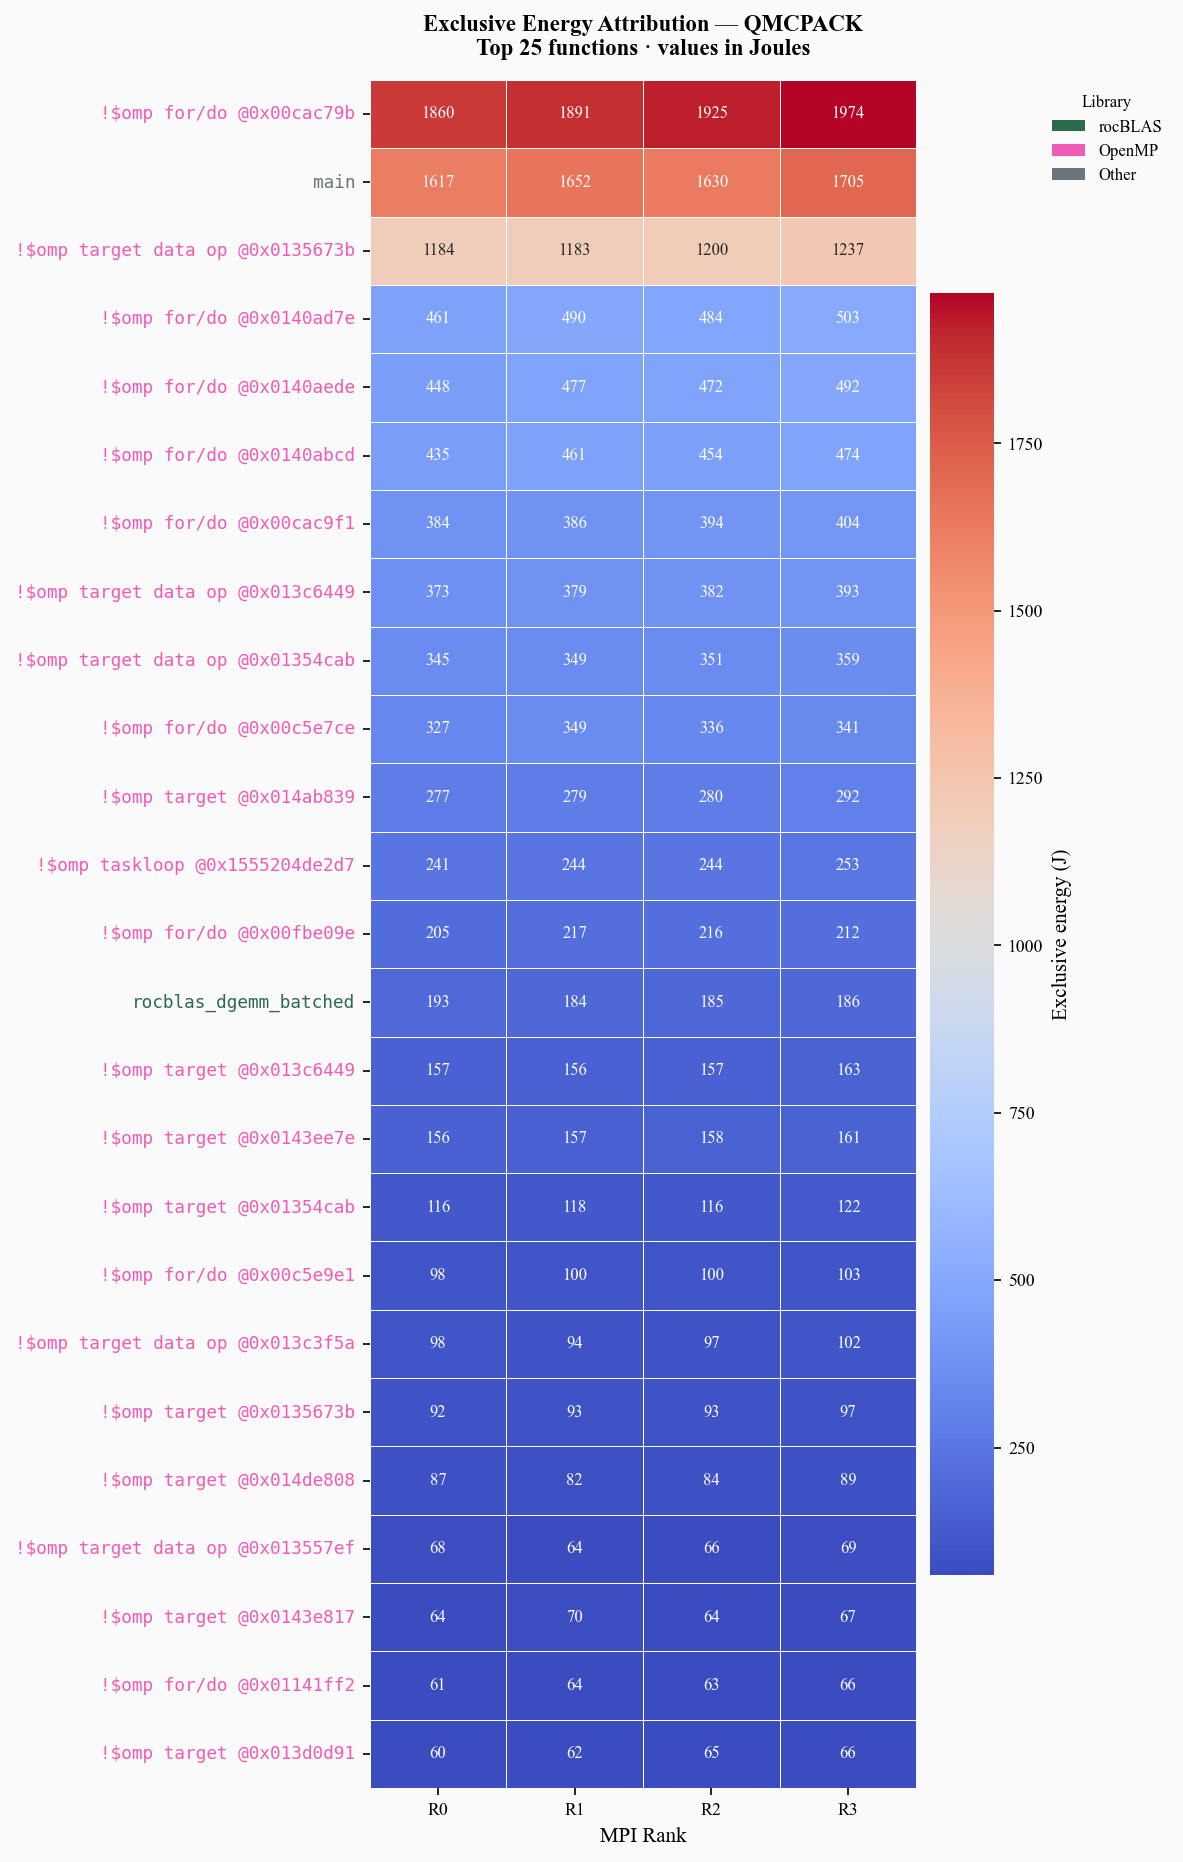

In [5]:
import seaborn as sns

def per_rank_energy_heatmap(bench_name: str, trial_path: Path,
                              top_n: int = 25, save_prefix: str = "fig2"):
    # Cached: this is the same attribution used by the library-breakdown cell
    # below, so each benchmark only pays for ensemble + 4× attribute() once.
    attr = get_attribution(trial_path)
    if attr is None or len(attr) == 0:
        print(f"  [skip] {bench_name}: no attribution data"); return

    attr = attr[attr['Library'] != 'MPI'].copy()

    pivot = (attr.groupby(['ShortName', 'Rank'])['Value'].sum()
               .unstack(fill_value=0.0))
    rank_cols = sorted(pivot.columns,
                       key=lambda s: int(re.search(r'\d+', s).group()))
    pivot = pivot[rank_cols].rename(
        columns={c: c.replace('MPI Rank ', 'R') for c in rank_cols})

    top_funcs = pivot.sum(axis=1).sort_values(ascending=False).head(top_n).index
    heat = pivot.loc[top_funcs]

    func_libs = attr.groupby('ShortName')['Library'].first().to_dict()
    LIB_HEX = {'rocBLAS': '#2d6a4f', 'rocSOLVER': '#e07a3a',
               'HIP Runtime': '#9b5de5', 'HPL': '#1a759f',
               'OpenMP': '#f15bb5', 'Other': '#6c757d'}

    fig_h = max(6, len(top_funcs) * 0.42 + 2)
    fig_w = max(8, heat.shape[1] * 1.0 + 4)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor=BG)
    ax.set_facecolor(BG)

    sns.heatmap(
        heat,
        annot=True,
        fmt='.0f',
        cmap='coolwarm',
        linewidths=0.4,
        linecolor='white',
        ax=ax,
        cbar_kws={'label': 'Exclusive energy (J)', 'shrink': 0.75, 'pad': 0.02},
        annot_kws={'size': 8},
    )

    for tick_label in ax.get_yticklabels():
        fn  = tick_label.get_text()
        lib = func_libs.get(fn, 'Other')
        tick_label.set_color(LIB_HEX.get(lib, '#6c757d'))
        tick_label.set_fontsize(8.5)
        tick_label.set_fontfamily('monospace')

    ax.set_xlabel('MPI Rank', fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8.5, rotation=0)
    ax.tick_params(axis='y', labelsize=8.5, rotation=0)
    ax.set_title(
        f'Exclusive Energy Attribution — {bench_name}\n'
        f'Top {len(top_funcs)} functions · values in Joules',
        fontweight='bold', pad=12)

    lib_handles = [mpatches.Patch(facecolor=LIB_HEX[lib], label=lib)
                   for lib in LIB_HEX
                   if lib in {func_libs.get(fn, 'Other') for fn in top_funcs}]
    ax.legend(handles=lib_handles, frameon=False, fontsize=8,
              bbox_to_anchor=(1.22, 1), loc='upper left', title='Library',
              title_fontsize=8)

    fig.tight_layout()
    fig.savefig(f'{save_prefix}_{bench_name}_heatmap.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

for bench_name, trial_path in BENCHMARKS.items():
    per_rank_energy_heatmap(bench_name, trial_path)


## Figures 3 & 4: Exclusive and Inclusive Energy Flamegraphs

Both flamegraphs are time-ordered: X axis = real time, Y axis = call depth, each bar = one function call.  
**Exclusive** (Fig 3): bar color encodes only the energy this function consumed itself (child calls subtracted). Hot bars are the literal source of power draw.  
**Inclusive** (Fig 4): bar color encodes total energy flowing *through* the call (including all descendants). Shows which high-level routines own the most energy.

Building flame data for HPG-MxP-Full … max_depth=10, min_dur_s=1.7 ms, window=[1.50, 49.22] s
  [build_flame] MPI Rank 0_Master_thread_callgraph.csv (one-time, will be cached)
  8,295 bars  ·  root inclusive ≈ 33587 J  ·  max bar incl = 33587 J  ·  max bar excl = 1730 J


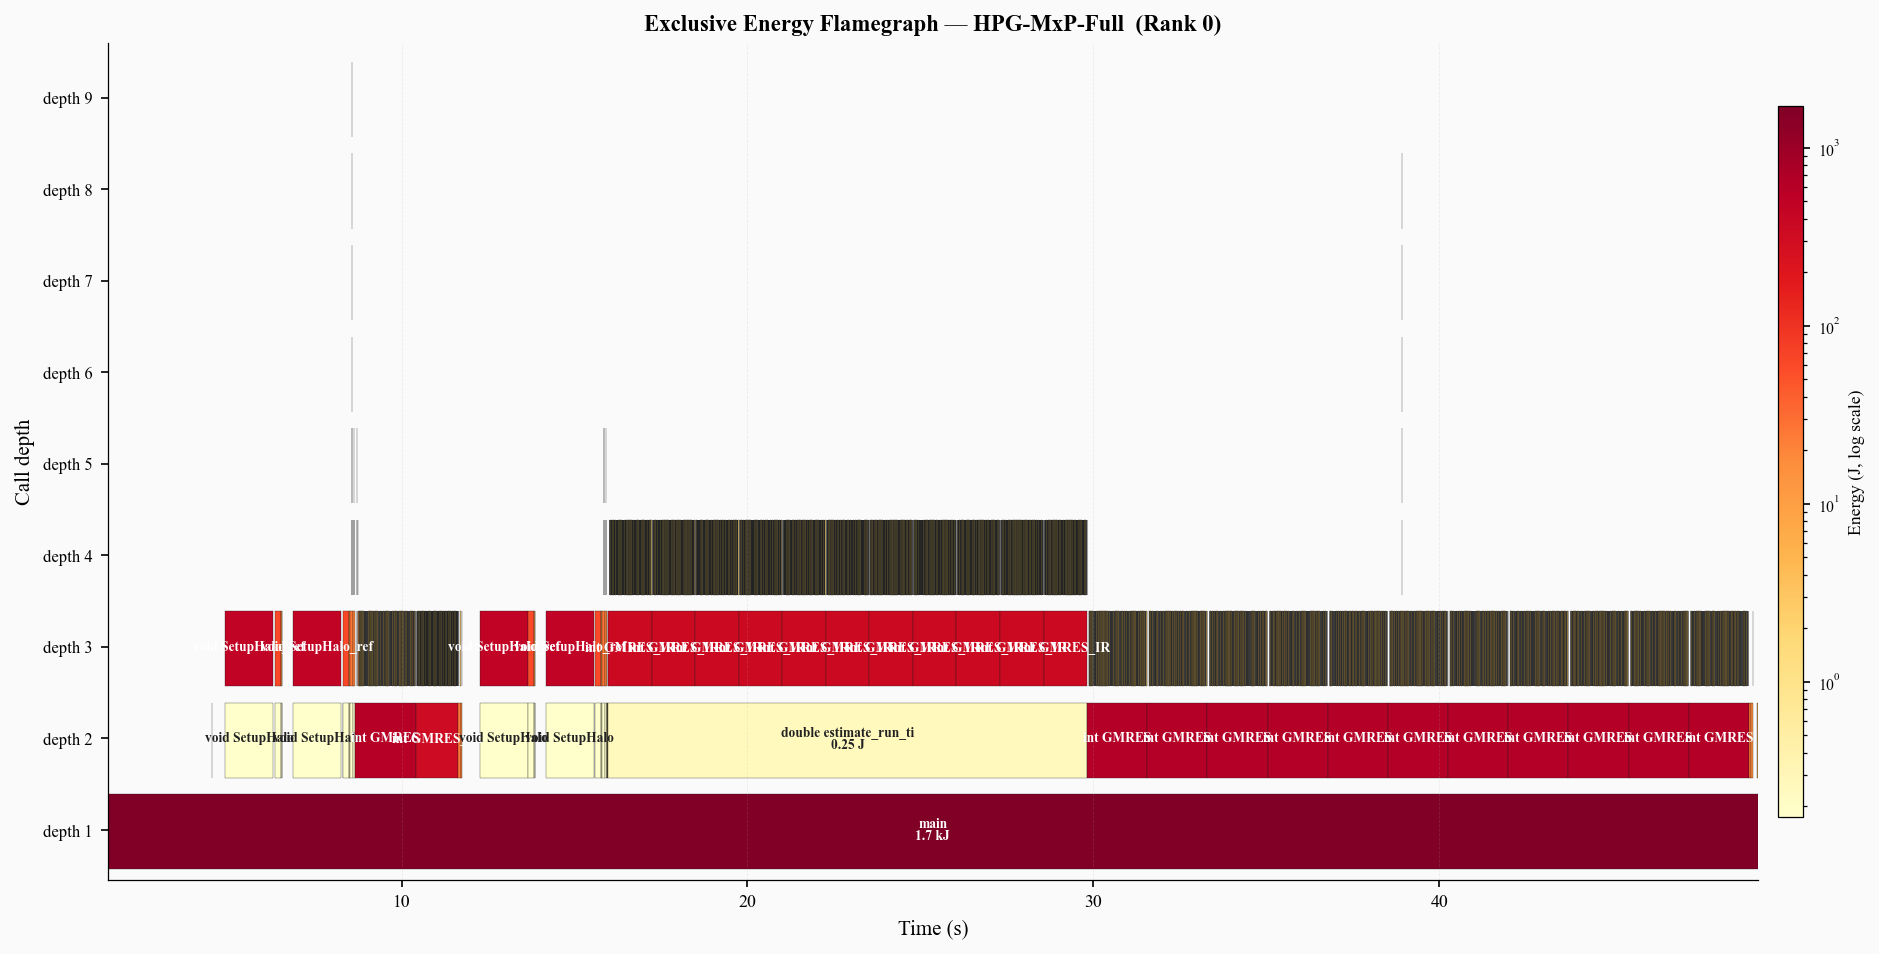

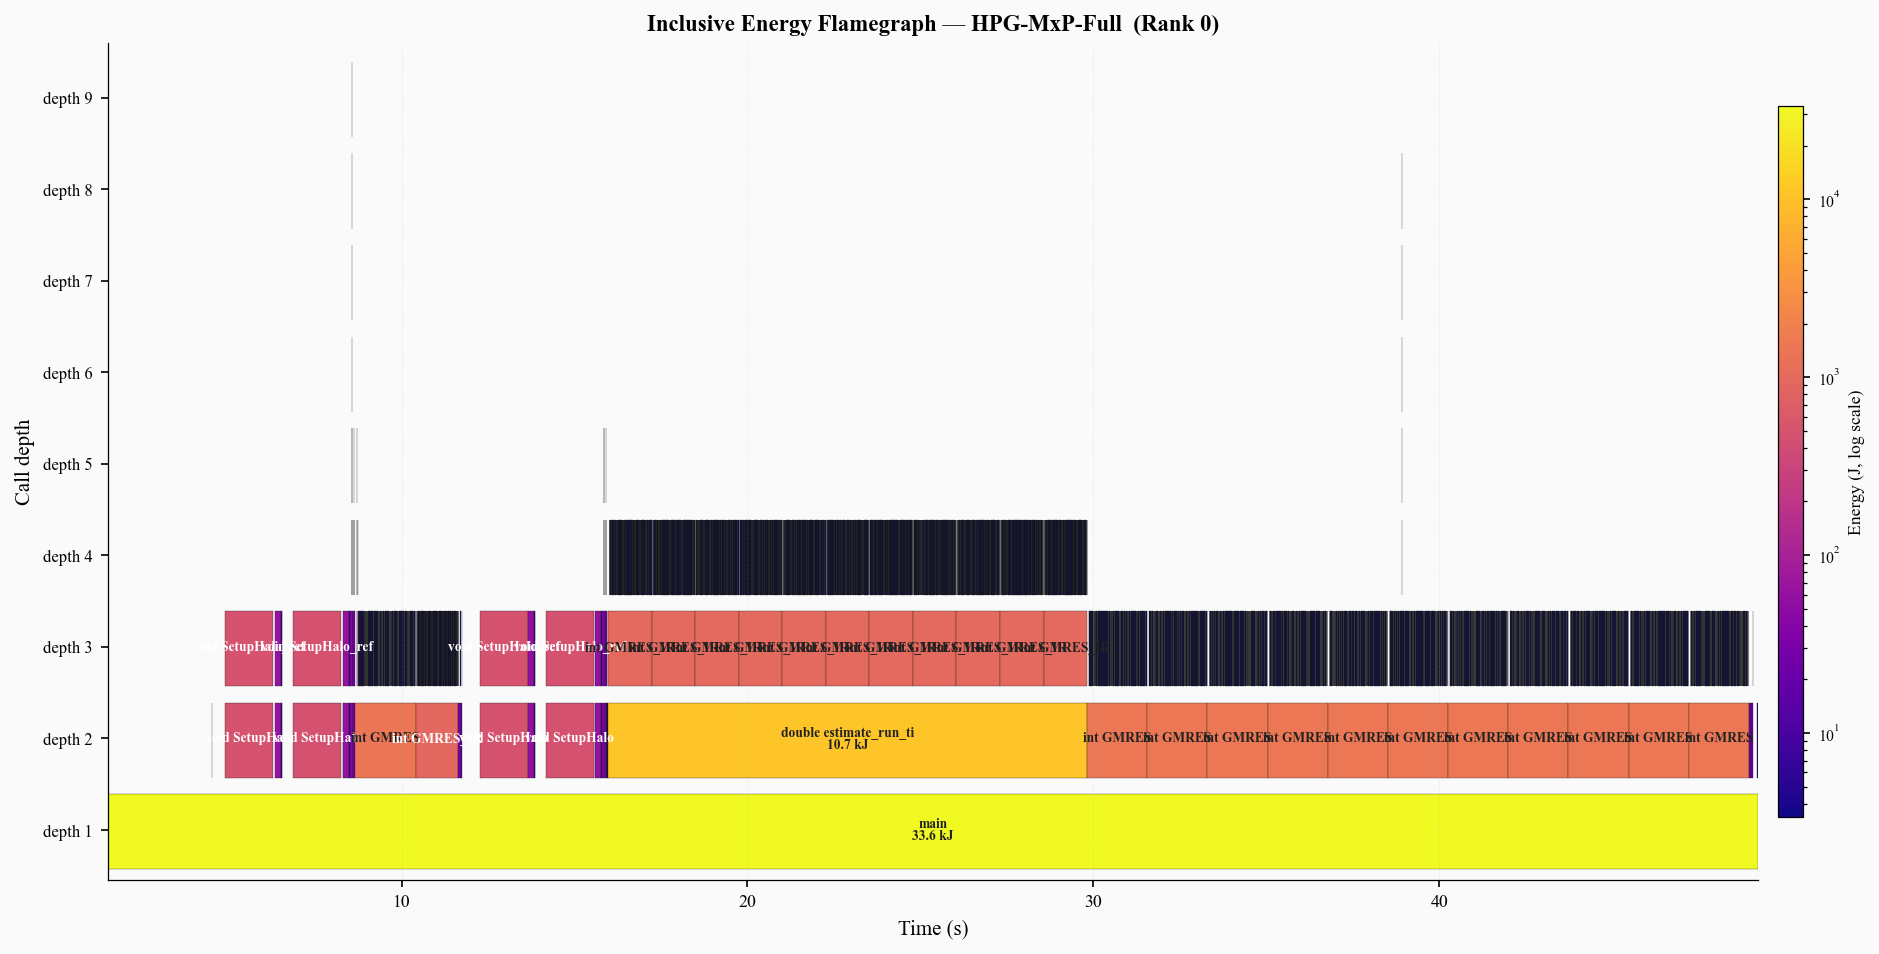

Building flame data for HPL … max_depth=12, min_dur_s=0.5 ms, window=[1.50, 72.30] s
  [build_flame] MPI Rank 0_Master_thread_callgraph.csv (one-time, will be cached)
  6,340 bars  ·  root inclusive ≈ 78036 J  ·  max bar incl = 78036 J  ·  max bar excl = 2747 J


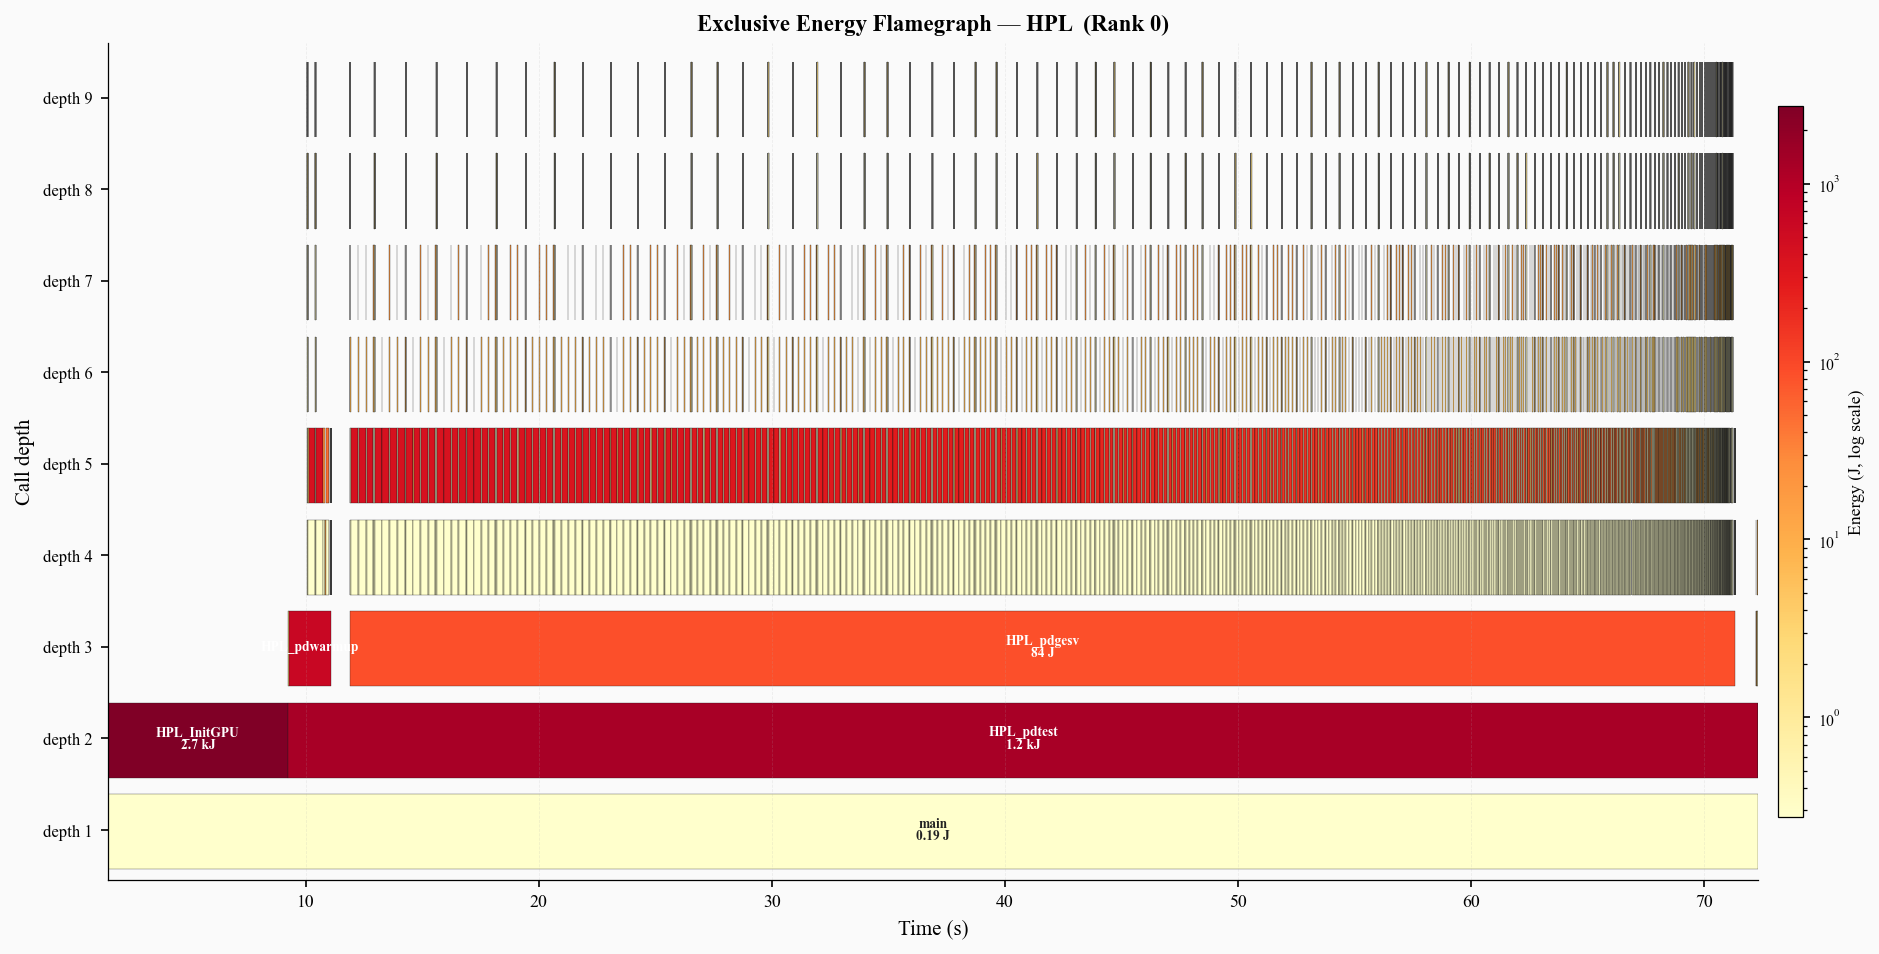

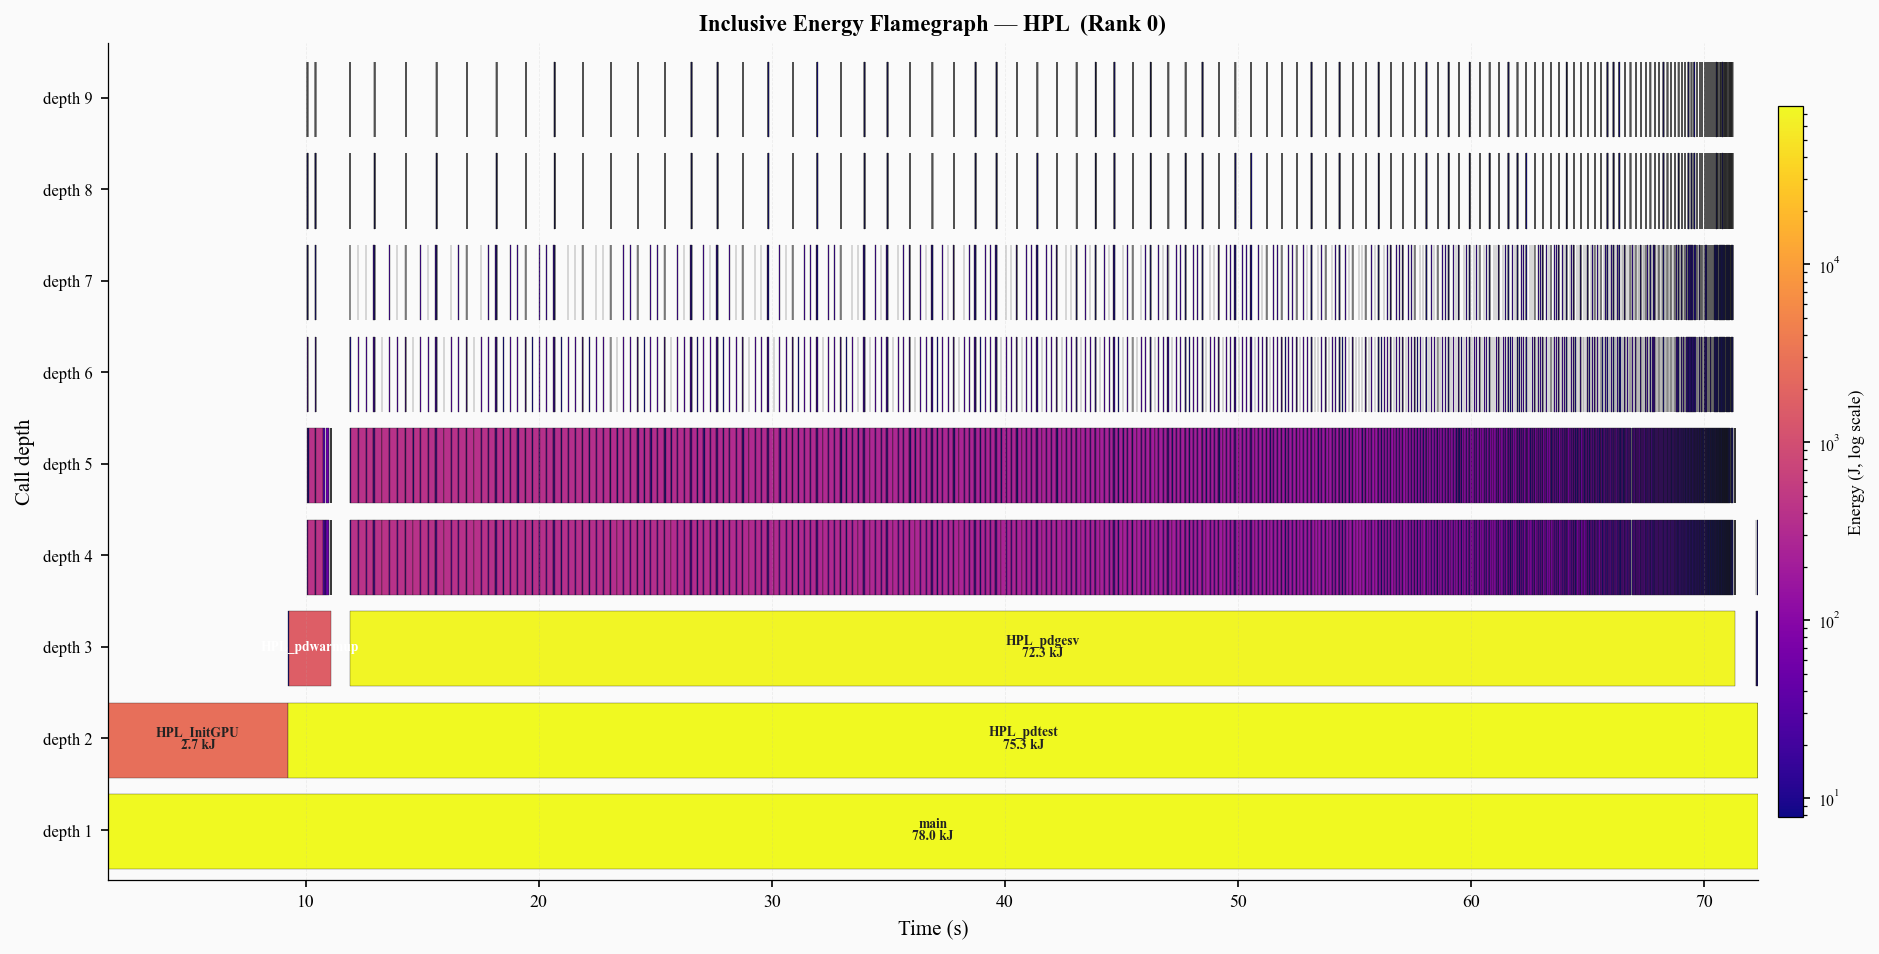

Building flame data for HPL-MxP … max_depth=7, min_dur_s=0.5 ms, window=[1.50, 27.99] s
  [build_flame] MPI Rank 0_Master_thread_callgraph.csv (one-time, will be cached)
  1,243 bars  ·  root inclusive ≈ 15618 J  ·  max bar incl = 15618 J  ·  max bar excl = 3321 J


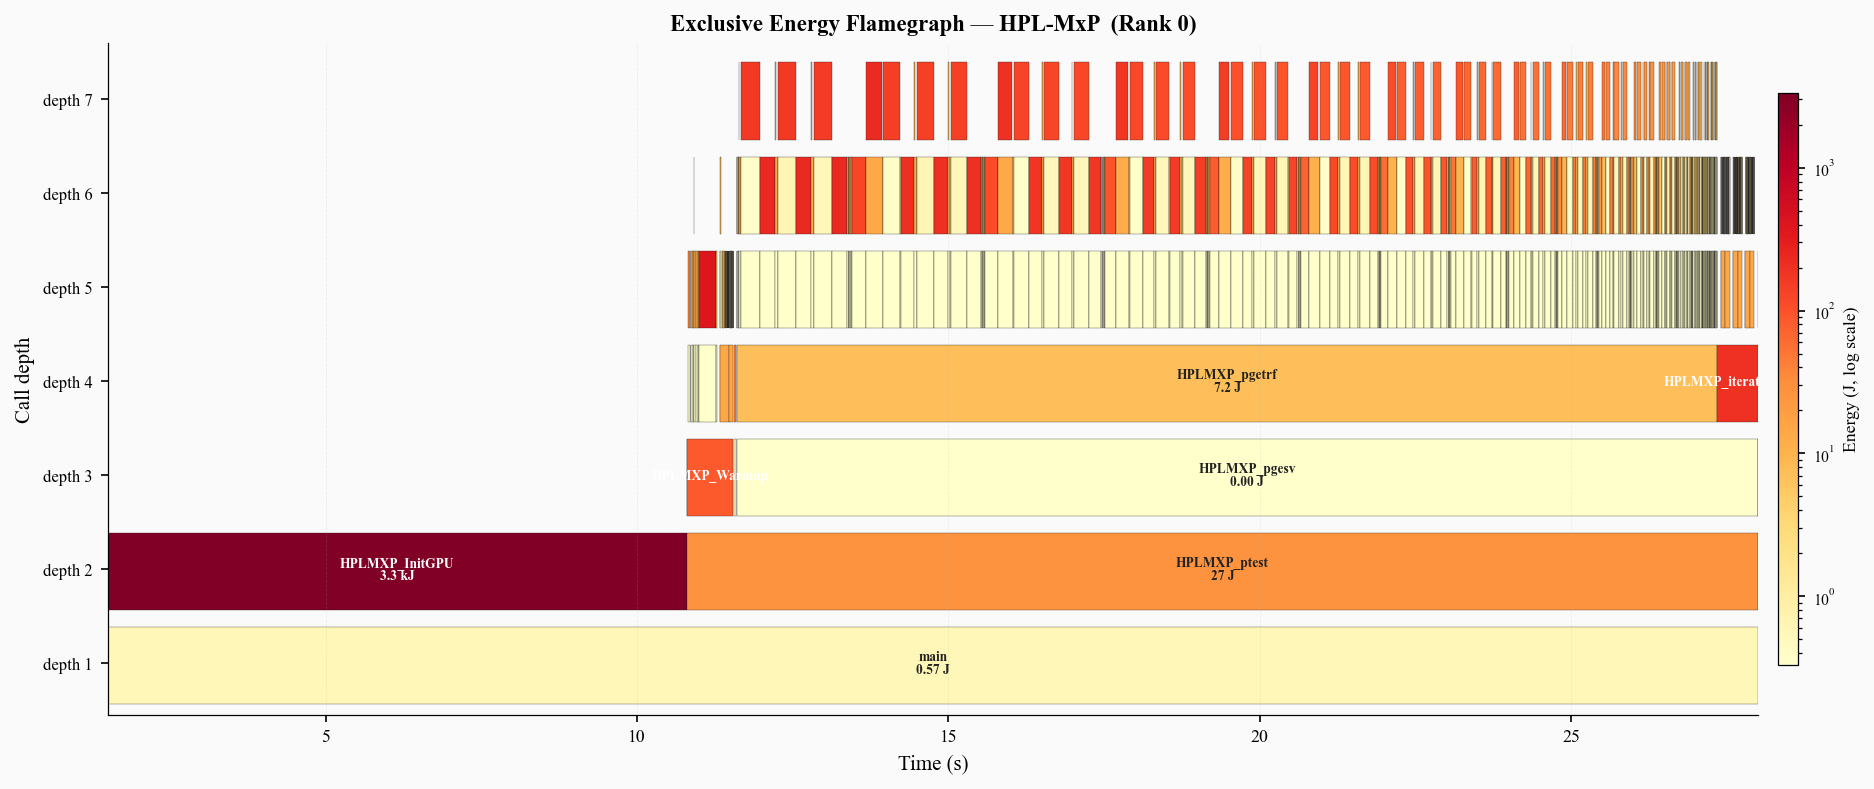

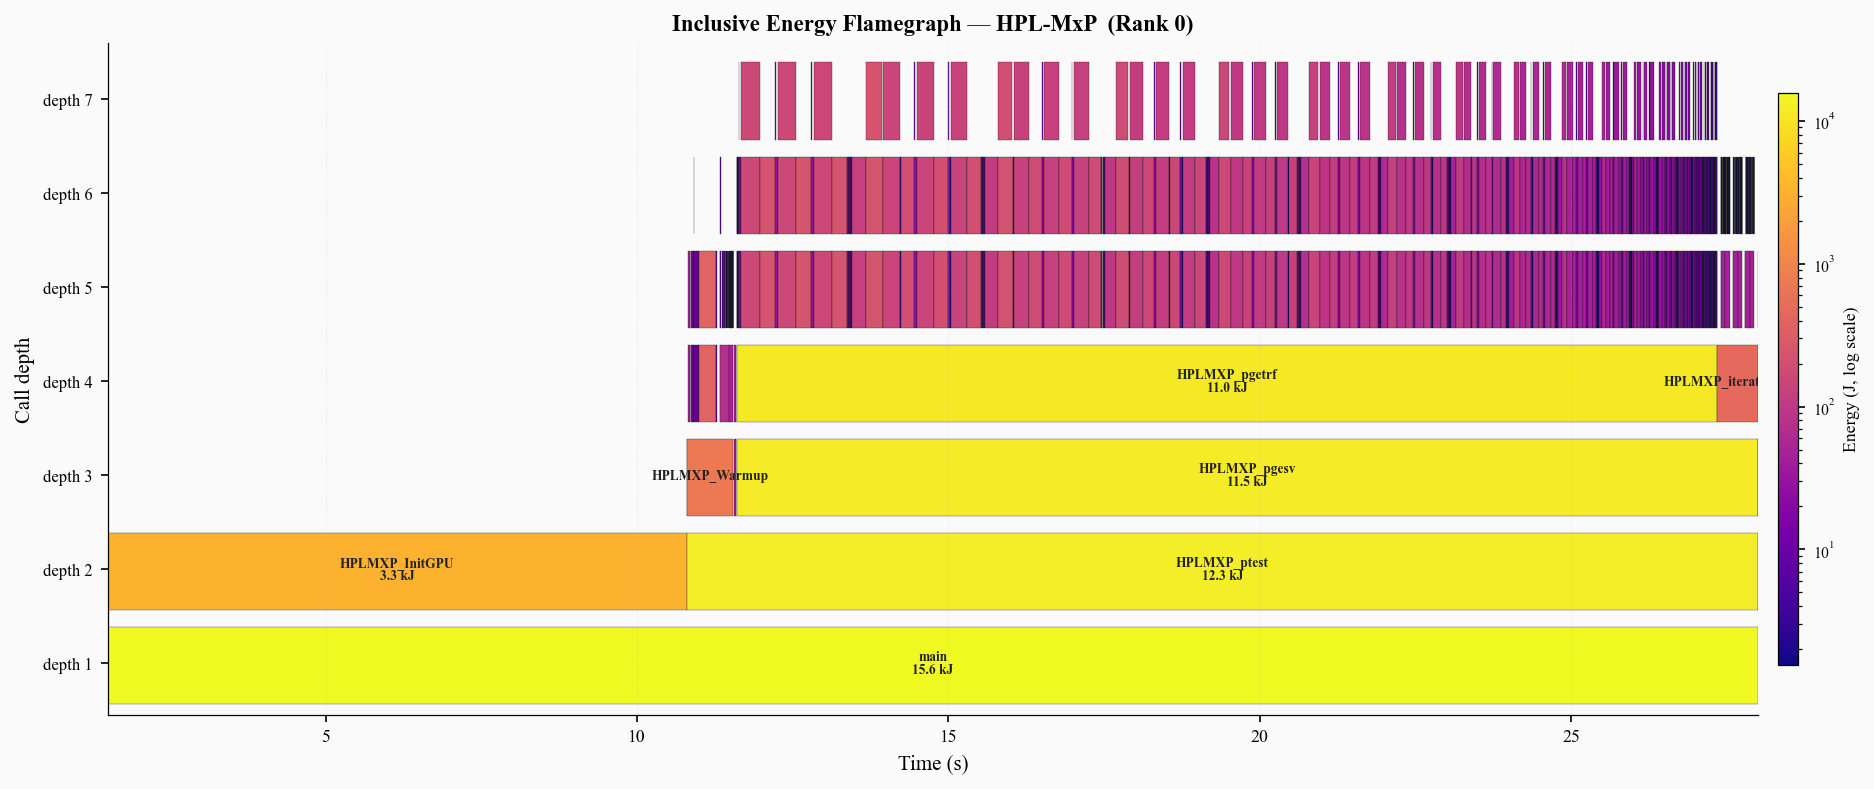

Building flame data for LSMS … max_depth=15, min_dur_s=0.5 ms, window=[1.51, 53.17] s
  [build_flame] MPI Rank 0_Master_thread_callgraph.csv (one-time, will be cached)
  1,540 bars  ·  root inclusive ≈ 27500 J  ·  max bar incl = 27500 J  ·  max bar excl = 3461 J


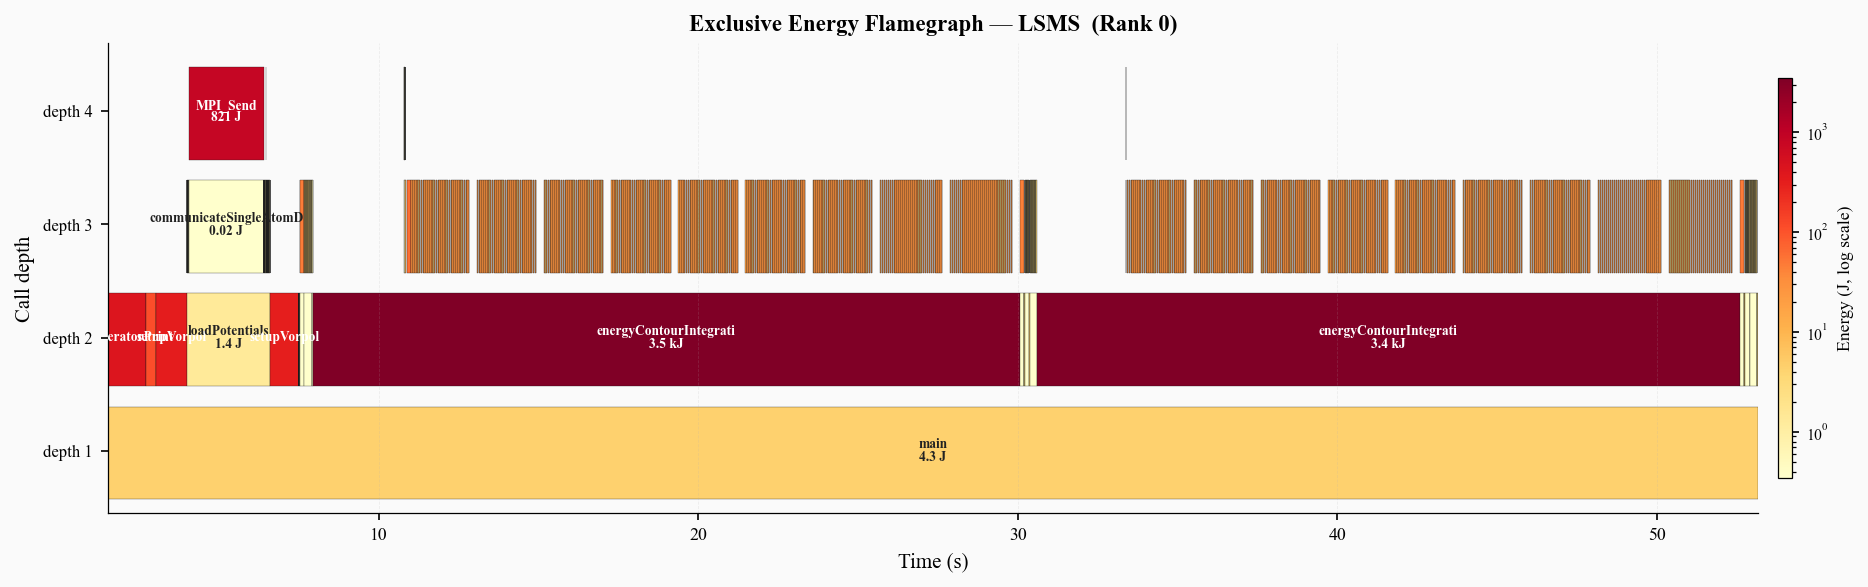

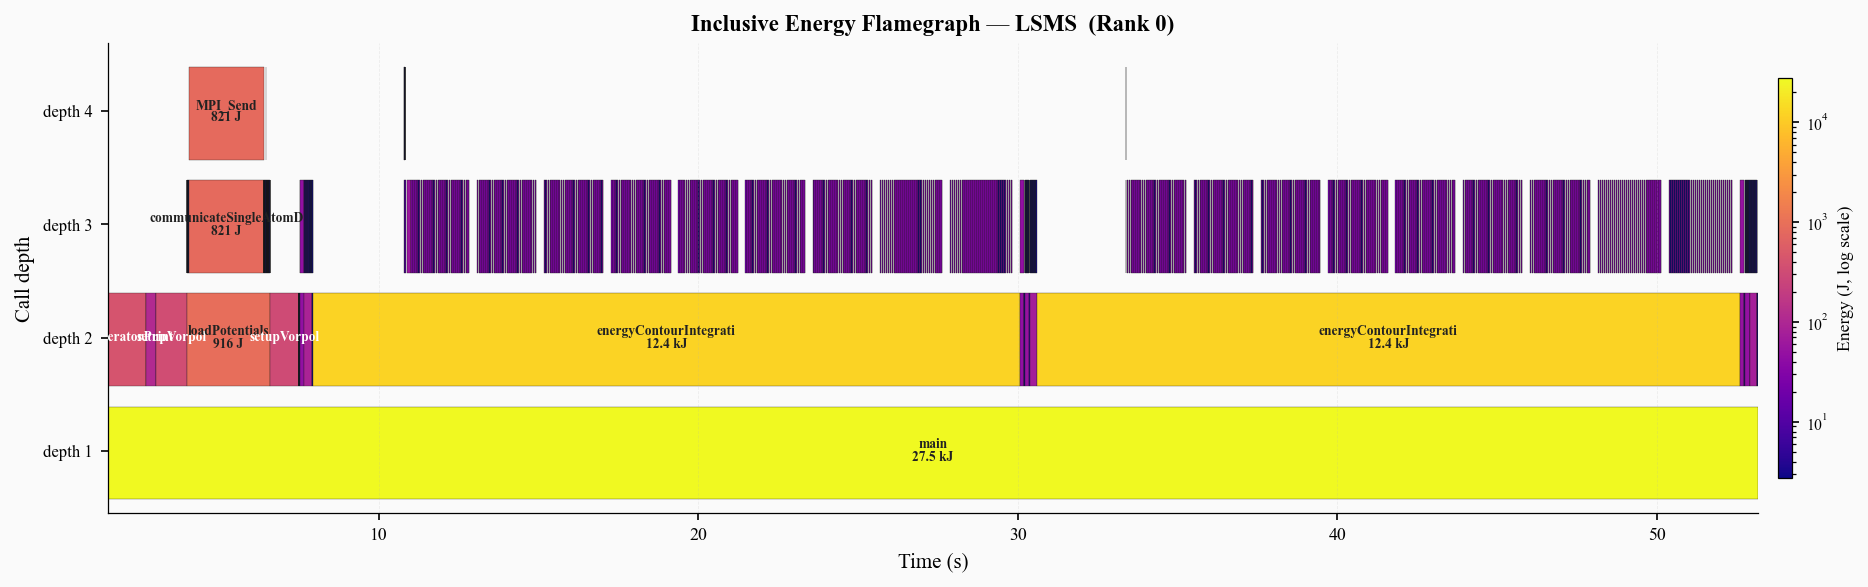

Building flame data for QMCPACK … max_depth=7, min_dur_s=0.5 ms, window=[1.50, 91.50] s
  [build_flame] MPI Rank 0_Master_thread_callgraph.csv (one-time, will be cached)
  7,639 bars  ·  root inclusive ≈ 35100 J  ·  max bar incl = 35100 J  ·  max bar excl = 6023 J


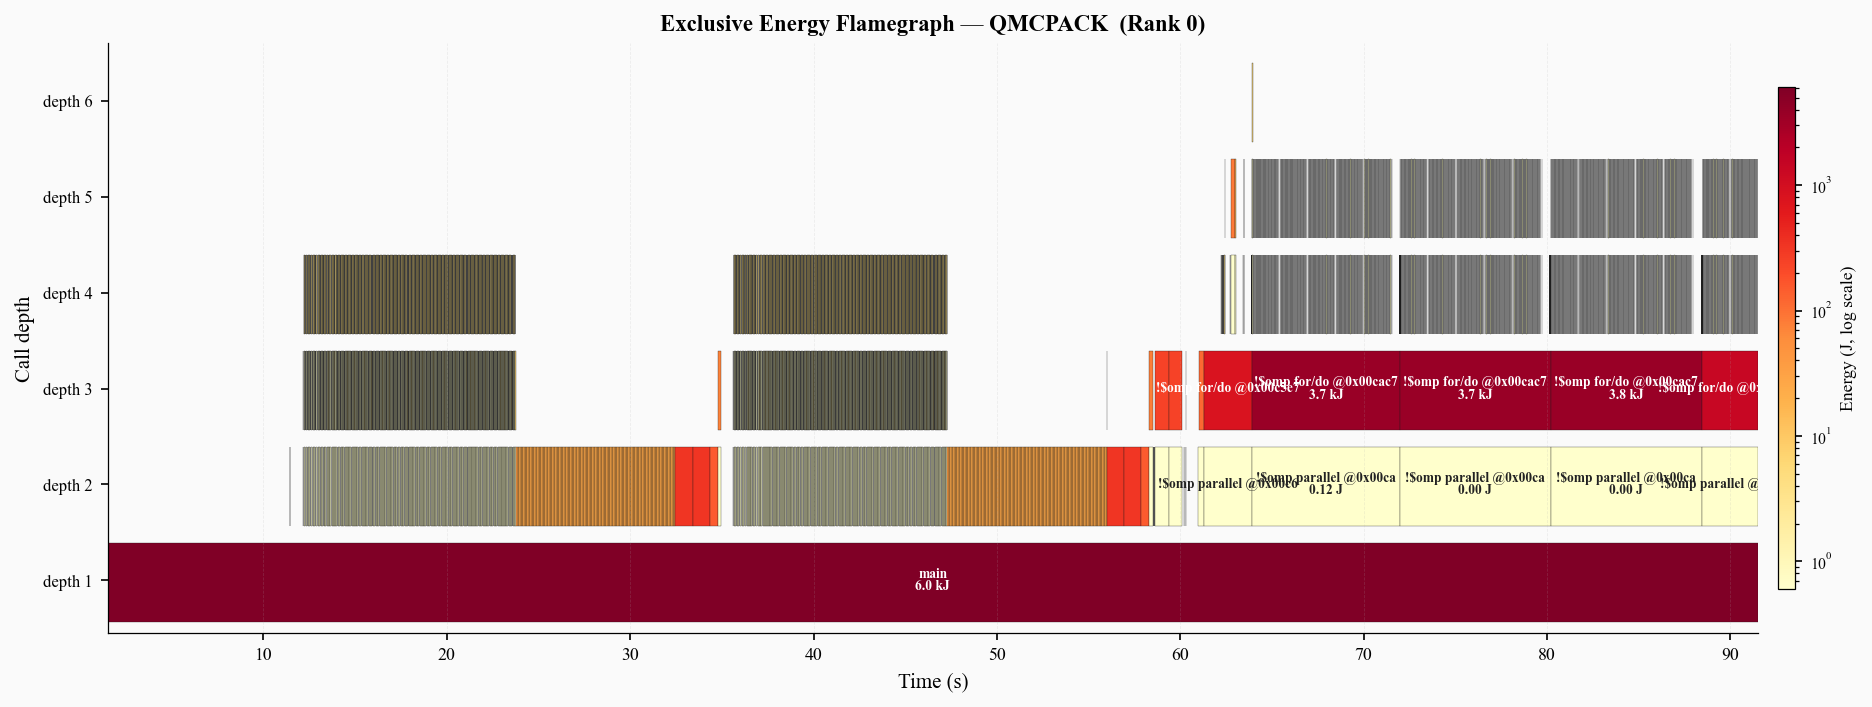

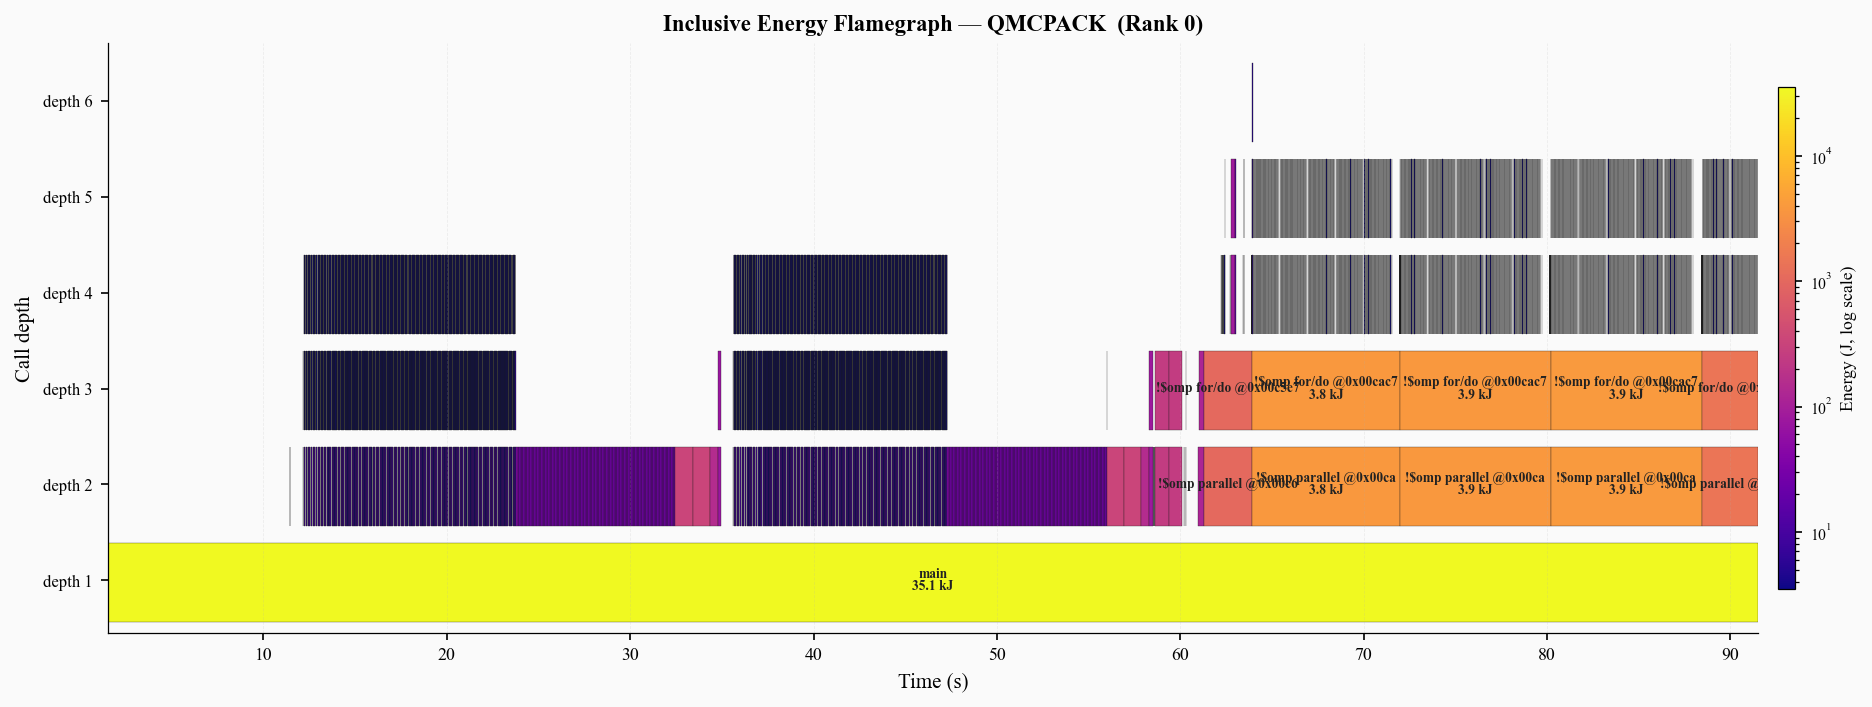

In [6]:
def integrate_windows(t0s, t1s, power_t, power_v):
    """Numerically integrate power over each [t0, t1] window."""
    out = np.zeros(len(t0s))
    for i, (t0, t1) in enumerate(zip(t0s, t1s)):
        if t1 <= t0: continue
        mask = (power_t > t0) & (power_t < t1)
        tw = np.empty(mask.sum() + 2)
        pw = np.empty_like(tw)
        tw[0]  = t0;  pw[0]  = float(np.interp(t0,  power_t, power_v))
        tw[-1] = t1;  pw[-1] = float(np.interp(t1,  power_t, power_v))
        tw[1:-1] = power_t[mask]; pw[1:-1] = power_v[mask]
        out[i] = float(np.sum((pw[:-1] + pw[1:]) * 0.5 * np.diff(tw))) if len(tw) >= 2 else 0.0
    return out


def pick_flame_params(cg_path: Path,
                      init_skip_s: float = 1.5,
                      max_window_s: float = 90.0,
                      hard_max_depth: int = 15,
                      target_max_bars: int = 15_000,
                      min_dur_floor_s: float = 0.0005):
    """Pick (max_depth, min_dur_s, t_window) from the trace itself so HPL-sized
    and HPG-MxP-sized benchmarks both render usefully.  Reads the callgraph
    via the shared cache — never hits disk twice for the same path."""
    df = get_callgraph(cg_path)
    if df.empty:
        return 5, 0.025, (0.0, max_window_s)

    trace_start = float(df['Start Time'].min())
    trace_end   = float(df['End Time'].max())
    t0 = trace_start + init_skip_s
    t1 = min(trace_end, t0 + max_window_s)
    t_window = (t0, t1)

    max_depth = int(min(hard_max_depth, df['Depth'].max()))

    in_window = (df['End Time'] > t0) & (df['Start Time'] < t1) & (df['Depth'] <= max_depth)
    durations = df.loc[in_window, 'Duration'].values
    if len(durations) == 0:
        return max_depth, 0.025, t_window

    min_dur = min_dur_floor_s
    n_bars  = int((durations >= min_dur).sum())
    while n_bars > target_max_bars and min_dur < 1.0:
        min_dur *= 1.5
        n_bars   = int((durations >= min_dur).sum())

    return max_depth, float(min_dur), t_window


def _build_flame_data(cg_path: Path, metrics_path: Path,
                      max_depth: int = 7, min_dur_s: float = 0.02,
                      t_window: tuple | None = None):
    """Filter the cached callgraph to (depth, duration, time-window),
    compute Inclusive/Exclusive energy per bar.  No disk I/O happens here."""
    df_raw = get_callgraph(cg_path)
    df = df_raw[(df_raw['Depth'] <= max_depth) &
                (df_raw['Duration'] >= min_dur_s)].copy()

    if t_window:
        t0w, t1w = t_window
        df = df[(df['End Time'] > t0w) & (df['Start Time'] < t1w)].copy()
        df['Start Time'] = df['Start Time'].clip(lower=t0w)
        df['End Time']   = df['End Time'].clip(upper=t1w)
        df['Duration']   = df['End Time'] - df['Start Time']

    df['Short']   = df['Name'].apply(short_name)
    df['Library'] = df['Name'].apply(classify)
    df = df.sort_values(['Start Time', 'Depth']).reset_index(drop=True)

    power_t, power_v = get_combined_power(metrics_path)
    if power_t is None:
        return None

    df['InclusiveE'] = integrate_windows(
        df['Start Time'].values, df['End Time'].values, power_t, power_v)

    starts = df['Start Time'].values
    ends   = df['End Time'].values
    depths = df['Depth'].values
    inc    = df['InclusiveE'].values
    excl   = inc.copy()

    for i in range(len(df)):
        d, s, e = depths[i], starts[i], ends[i]
        child_mask = (depths == d + 1) & (starts >= s) & (ends <= e)
        excl[i] = max(0.0, inc[i] - inc[child_mask].sum())

    df['ExclusiveE'] = excl
    return df


def get_flame_data(cg_path: Path, metrics_path: Path,
                   max_depth: int, min_dur_s: float, t_window: tuple,
                   *, verbose: bool = True):
    """Cached: shared by Figs 3/4 and Figs 5/6 so the heavy filter +
    integration only happens once per (cg_path, params) tuple."""
    key = (str(cg_path), int(max_depth),
           round(float(min_dur_s), 6),
           round(float(t_window[0]), 6),
           round(float(t_window[1]), 6))
    if key in _FLAME_CACHE:
        return _FLAME_CACHE[key]
    if verbose:
        print(f"  [build_flame] {cg_path.name} (one-time, will be cached)")
    result = _build_flame_data(cg_path, metrics_path, max_depth, min_dur_s, t_window)
    _FLAME_CACHE[key] = result
    return result


build_flame_data = get_flame_data


def _format_joules(j: float) -> str:
    if j >= 1000:
        return f"{j/1000:.1f} kJ"
    if j >= 10:
        return f"{j:.0f} J"
    if j >= 1:
        return f"{j:.1f} J"
    return f"{j:.2f} J"


def _flame_color_norm(energies: np.ndarray):
    """Pick LogNorm if the energy range spans more than ~10×, else linear."""
    pos = energies[energies > 0]
    if len(pos) == 0:
        return plt.Normalize(vmin=0, vmax=1.0)
    vmax = float(pos.max())
    vmin = float(max(pos.min(), vmax * 1e-4))
    if vmax / max(vmin, 1e-12) >= 10:
        return mcolors.LogNorm(vmin=vmin, vmax=vmax)
    return plt.Normalize(vmin=0, vmax=vmax)


def draw_flamegraph(df: pd.DataFrame, energy_col: str, title: str,
                    cmap_name: str = 'YlOrRd', save_path: str | None = None,
                    label_min_frac: float = 0.015):
    if df is None or df.empty:
        print(f"  [skip] no data for {title}"); return

    energies = df[energy_col].values
    norm     = _flame_color_norm(energies)
    cmap     = plt.get_cmap(cmap_name)

    max_d   = int(df['Depth'].max())
    t_start = df['Start Time'].min()
    t_end   = df['End Time'].max()
    span    = t_end - t_start

    fig_h = max(4, max_d * 0.55 + 1.5)
    fig, ax = plt.subplots(figsize=(14, fig_h), facecolor=BG)
    ax.set_facecolor(BG)

    for _, row in df.iterrows():
        e = row[energy_col]
        color = cmap(norm(e)) if e > 0 else cmap(0.0)
        rect  = mpatches.FancyBboxPatch(
            (row['Start Time'], row['Depth'] - 0.43),
            max(row['Duration'], 0.0),
            0.82,
            boxstyle='square,pad=0',
            facecolor=color, edgecolor='#1a1a1a', linewidth=0.15,
        )
        ax.add_patch(rect)

        if span > 0 and row['Duration'] / span > label_min_frac:
            brightness = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
            txt_color  = 'white' if brightness < 0.55 else '#222'
            label = row['Short'][:22]
            if row['Duration'] / span > 0.04:
                label = f"{label}\n{_format_joules(e)}"
            ax.text(row['Start Time'] + row['Duration'] * 0.5,
                    row['Depth'],
                    label,
                    ha='center', va='center',
                    fontsize=6.5, color=txt_color, fontweight='bold',
                    clip_on=True, linespacing=0.95)

    ax.set_xlim(t_start, t_end)
    ax.set_ylim(0.45, max_d + 0.6)
    ax.set_yticks(range(1, max_d + 1))
    ax.set_yticklabels([f'depth {d}' for d in range(1, max_d + 1)], fontsize=8)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Call depth', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.18, linestyle='--')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, shrink=0.85, pad=0.01, aspect=28)
    cb.set_label('Energy (J, log scale)' if isinstance(norm, mcolors.LogNorm)
                 else 'Energy (J)', fontsize=8.5)
    cb.ax.tick_params(labelsize=7.5)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, facecolor=BG, bbox_inches='tight')
    plt.show()


for bench_name, trial_path in BENCHMARKS.items():
    cg_path = trial_path / 'MPI Rank 0_Master_thread_callgraph.csv'
    m_path  = trial_path / 'MPI Rank 0_metrics.csv'
    if not cg_path.exists() or not m_path.exists():
        print(f"  [skip] {bench_name}: missing rank-0 files"); continue

    max_depth, min_dur_s, t_window = pick_flame_params(cg_path)
    print(f"Building flame data for {bench_name} … "
          f"max_depth={max_depth}, min_dur_s={min_dur_s*1000:.1f} ms, "
          f"window=[{t_window[0]:.2f}, {t_window[1]:.2f}] s")

    flame_df = get_flame_data(cg_path, m_path, max_depth, min_dur_s, t_window)

    if flame_df is None or flame_df.empty:
        print(f"  [skip] {bench_name}: no data"); continue

    inc_root = flame_df[flame_df['Depth'] == flame_df['Depth'].min()]['InclusiveE'].sum()
    print(f"  {len(flame_df):,} bars  ·  root inclusive ≈ {inc_root:.0f} J  ·  "
          f"max bar incl = {flame_df['InclusiveE'].max():.0f} J  ·  "
          f"max bar excl = {flame_df['ExclusiveE'].max():.0f} J")

    draw_flamegraph(flame_df, 'ExclusiveE',
                    f'Exclusive Energy Flamegraph — {bench_name}  (Rank 0)',
                    cmap_name='YlOrRd',
                    save_path=f'fig3_exclusive_flame_{bench_name}.pdf')

    draw_flamegraph(flame_df, 'InclusiveE',
                    f'Inclusive Energy Flamegraph — {bench_name}  (Rank 0)',
                    cmap_name='plasma',
                    save_path=f'fig4_inclusive_flame_{bench_name}.pdf')


## Figures 5 & 6: Flamegraphs Synced With the GPU Power Curve

Same exclusive/inclusive flamegraphs as Figs 3 & 4, now stacked under the
instantaneous GPU power trace on a shared x-axis. This lets you read the
power draw against the callgraph at any time instant — power spikes line up
vertically with whichever bars are on the CPU at that moment.

- **Top panel** — combined GPU power across all 4 visible devices (W),
  derived by differentiating the energy counters. Mean and peak are noted.
- **Bottom panel** — flamegraph colored by energy (exclusive in Fig 5,
  inclusive in Fig 6).

HPG-MxP-Full: 8,295 bars  ·  power samples: 5,964  ·  window [1.50, 49.22] s


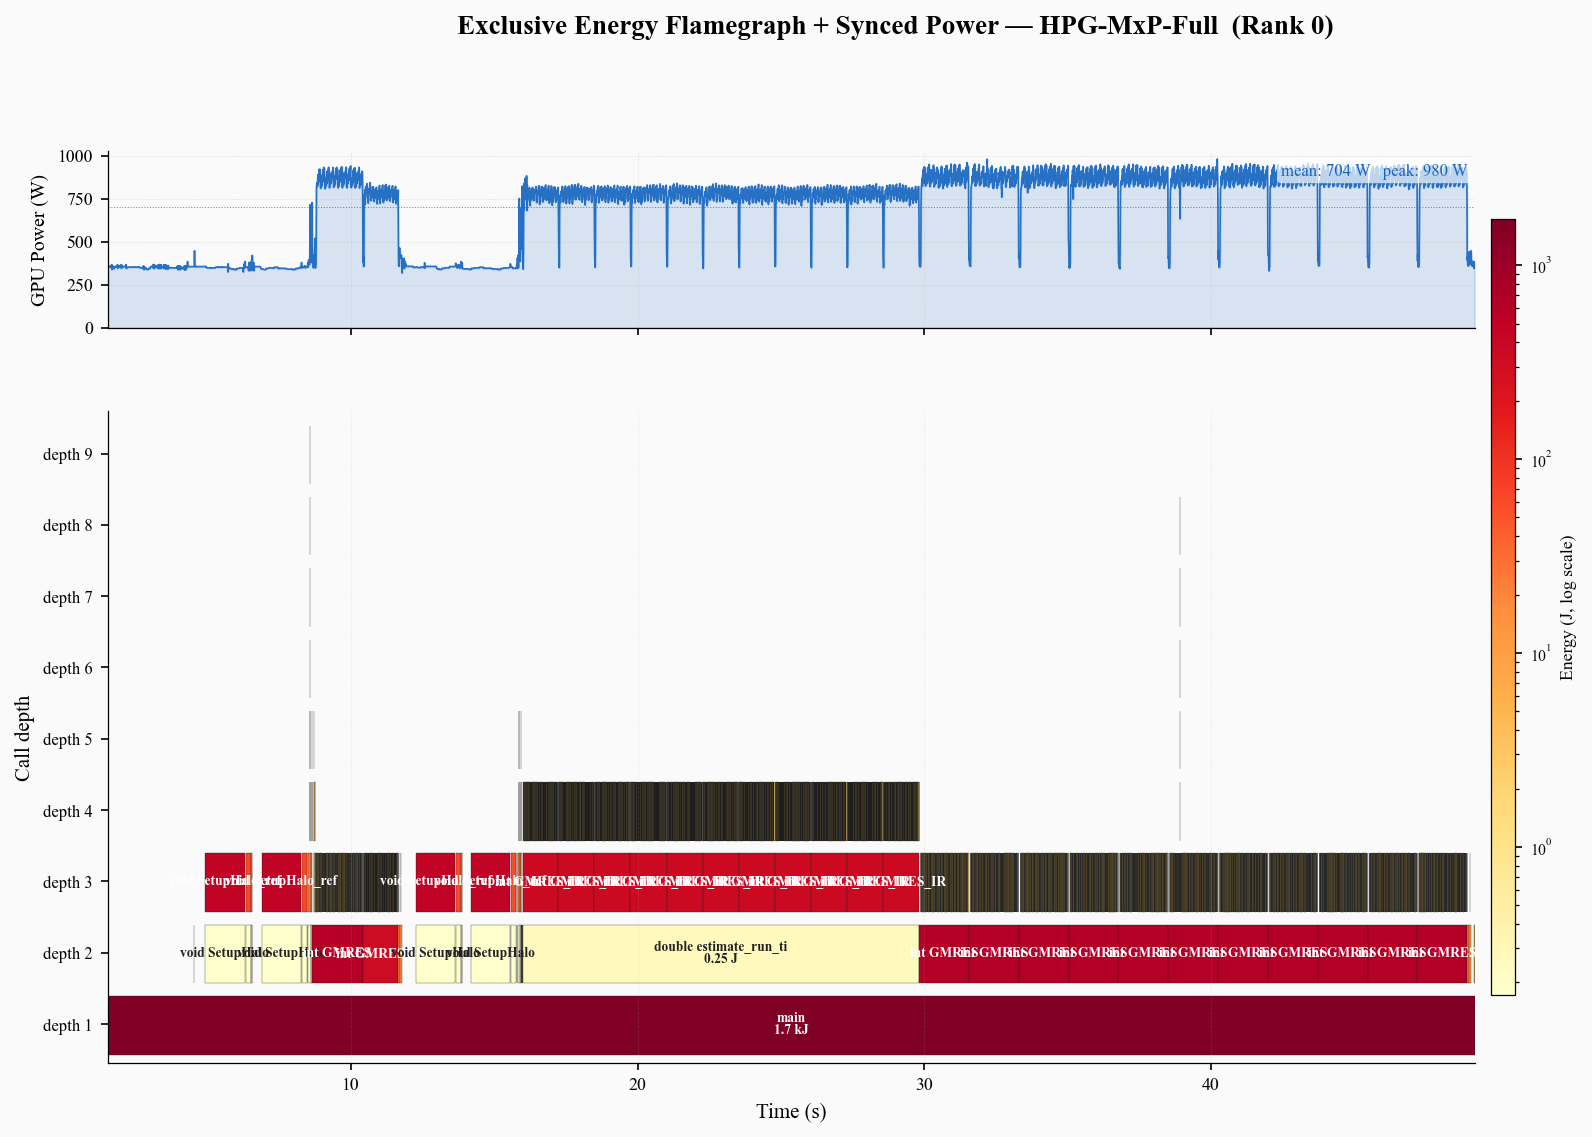

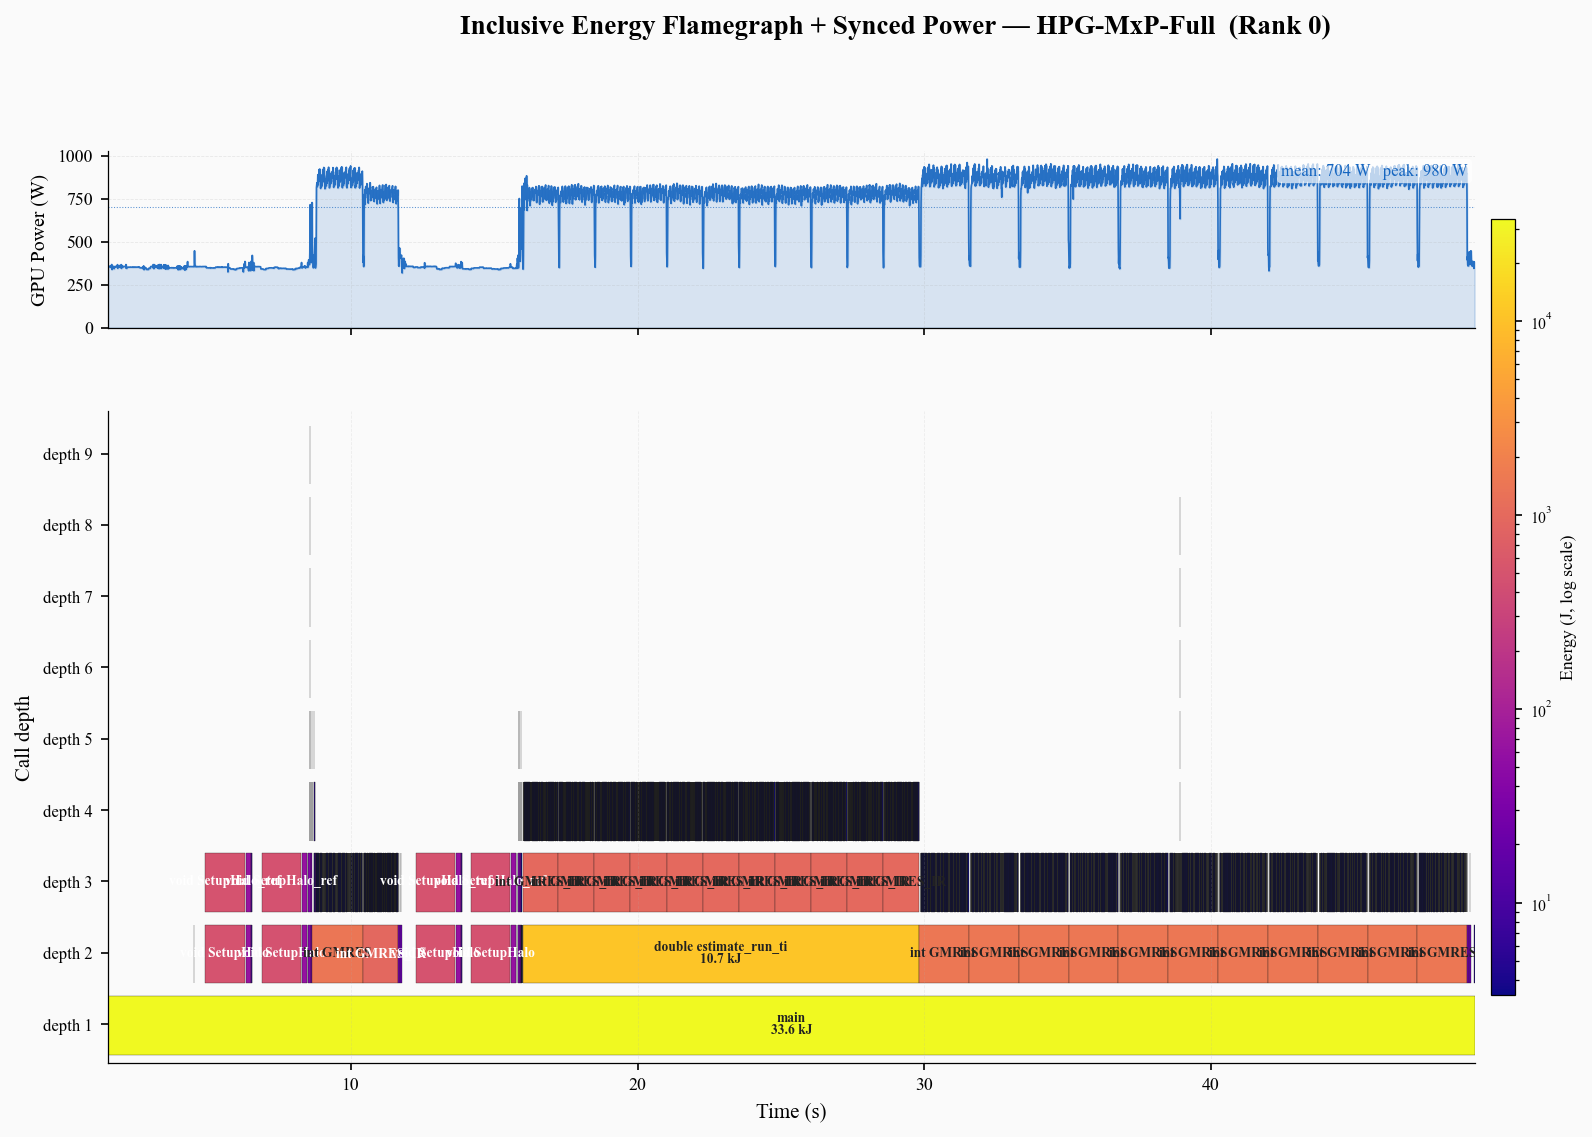

HPL: 6,340 bars  ·  power samples: 8,850  ·  window [1.50, 72.30] s


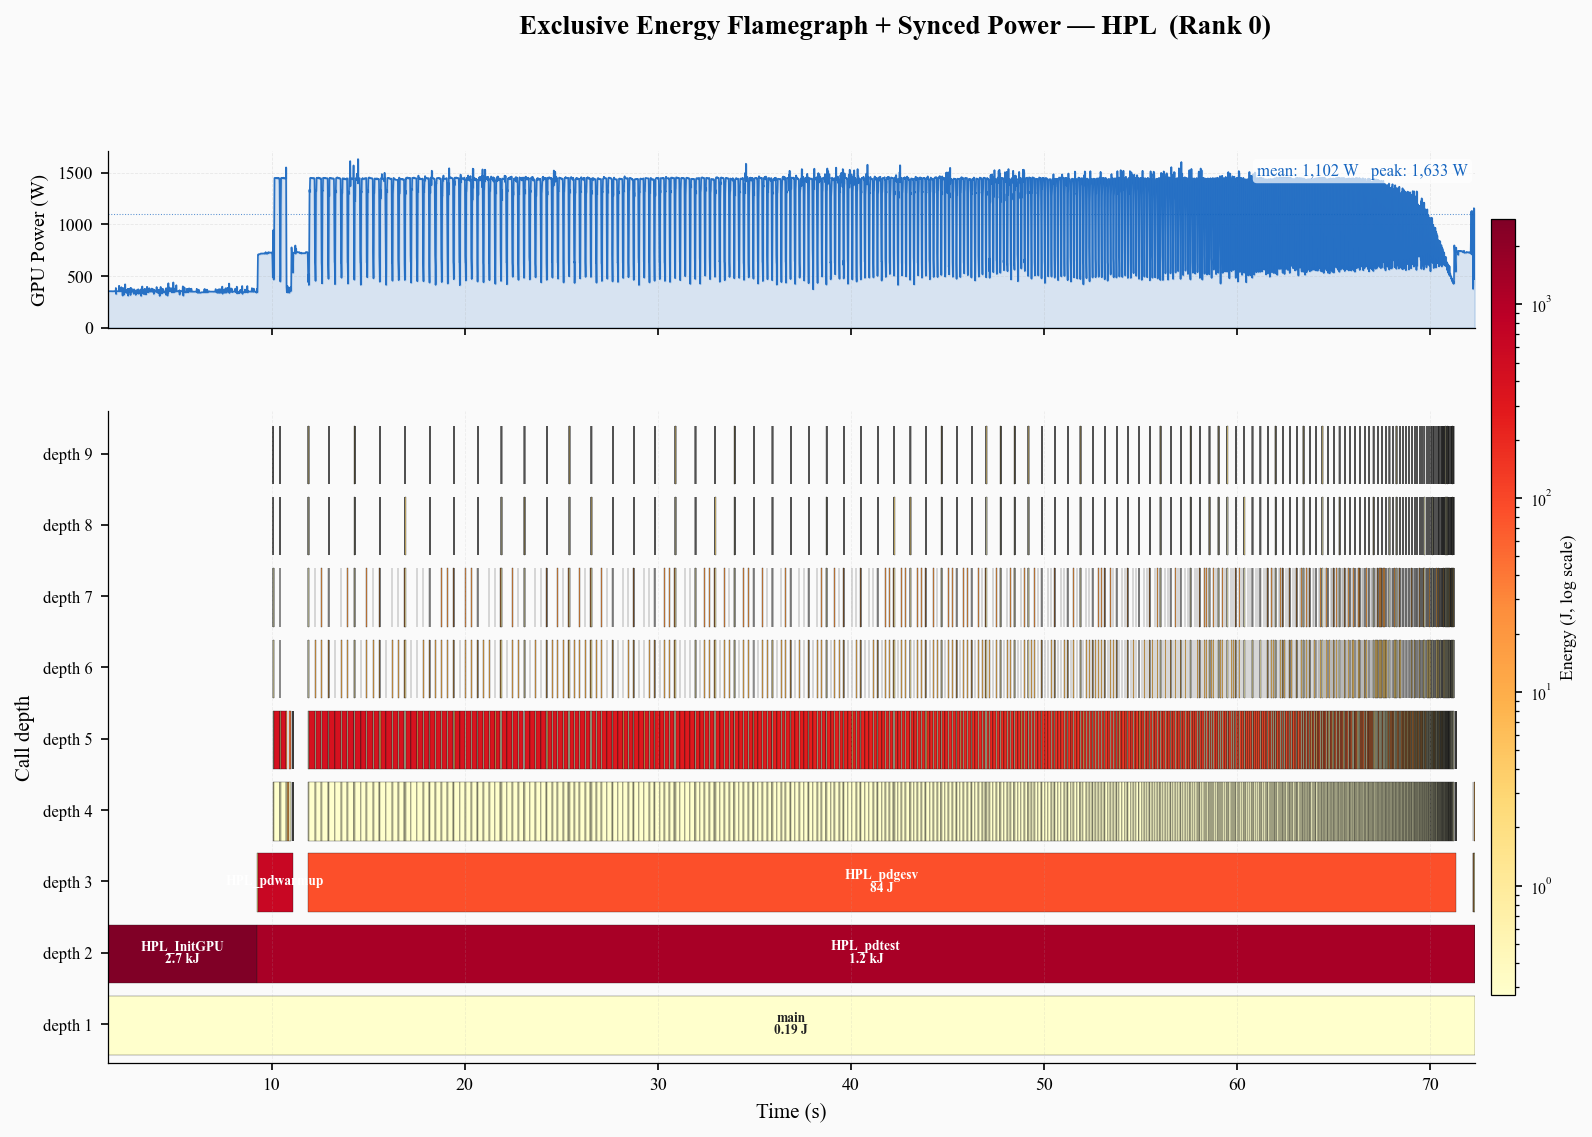

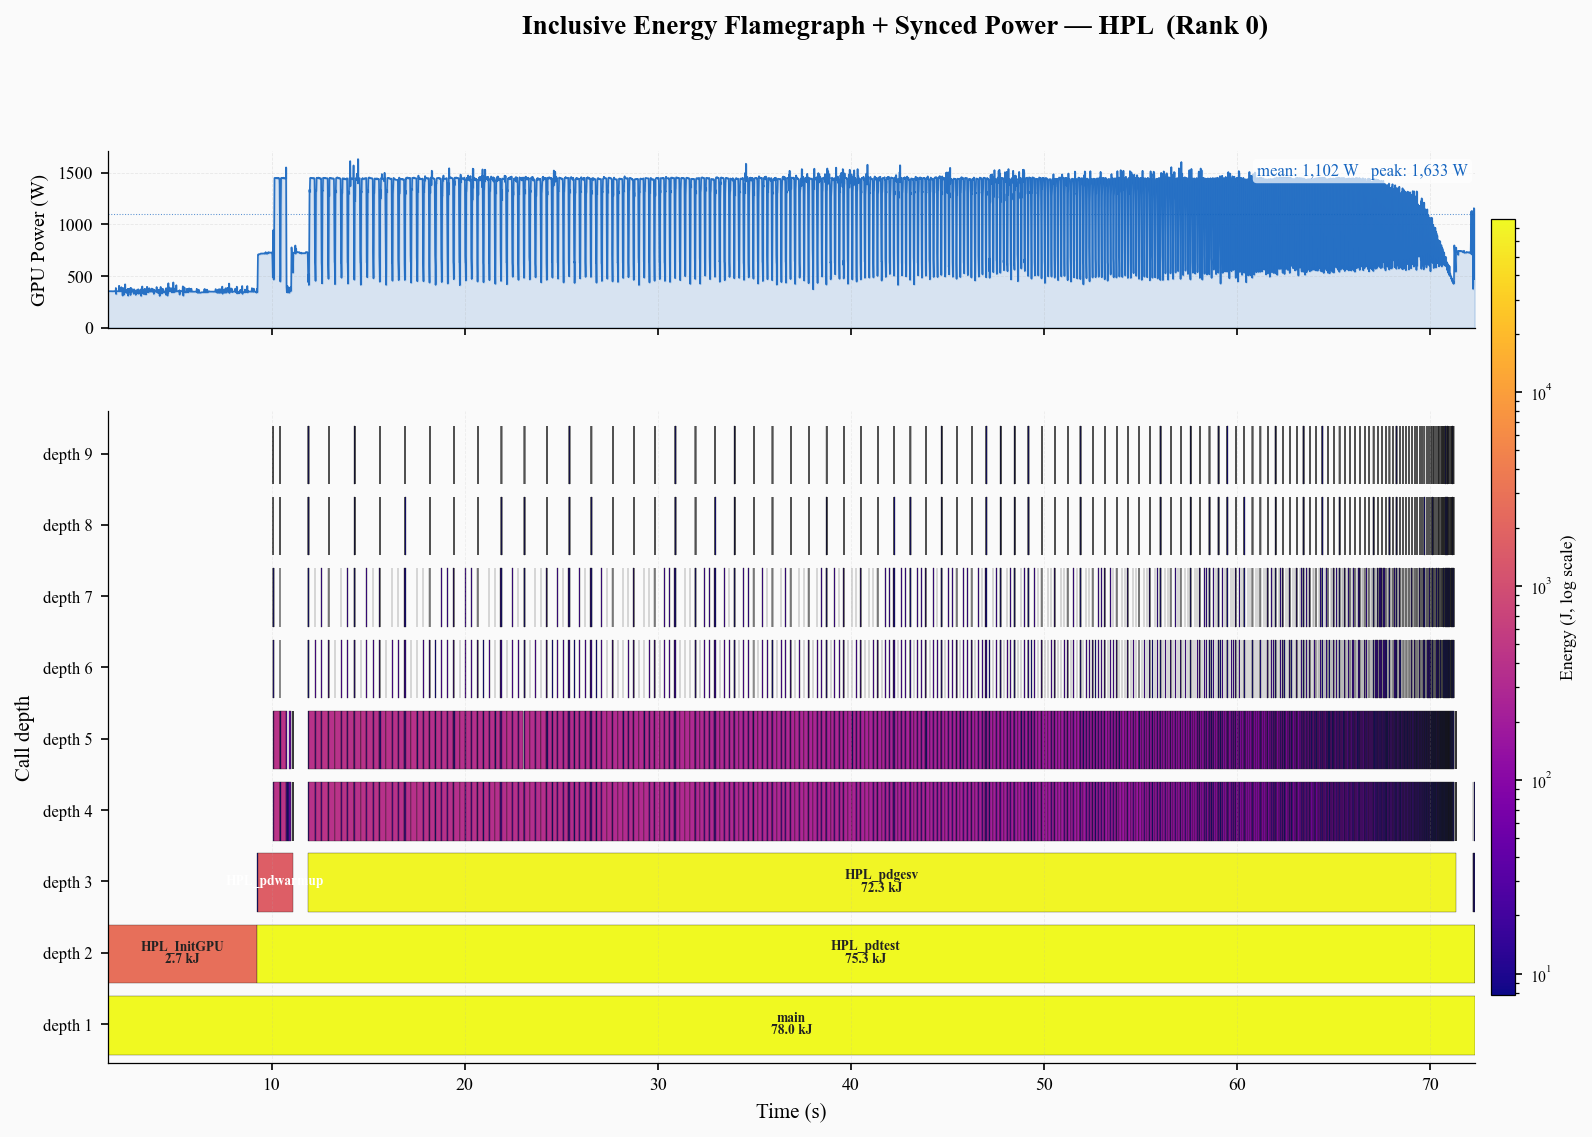

HPL-MxP: 1,243 bars  ·  power samples: 3,311  ·  window [1.50, 27.99] s


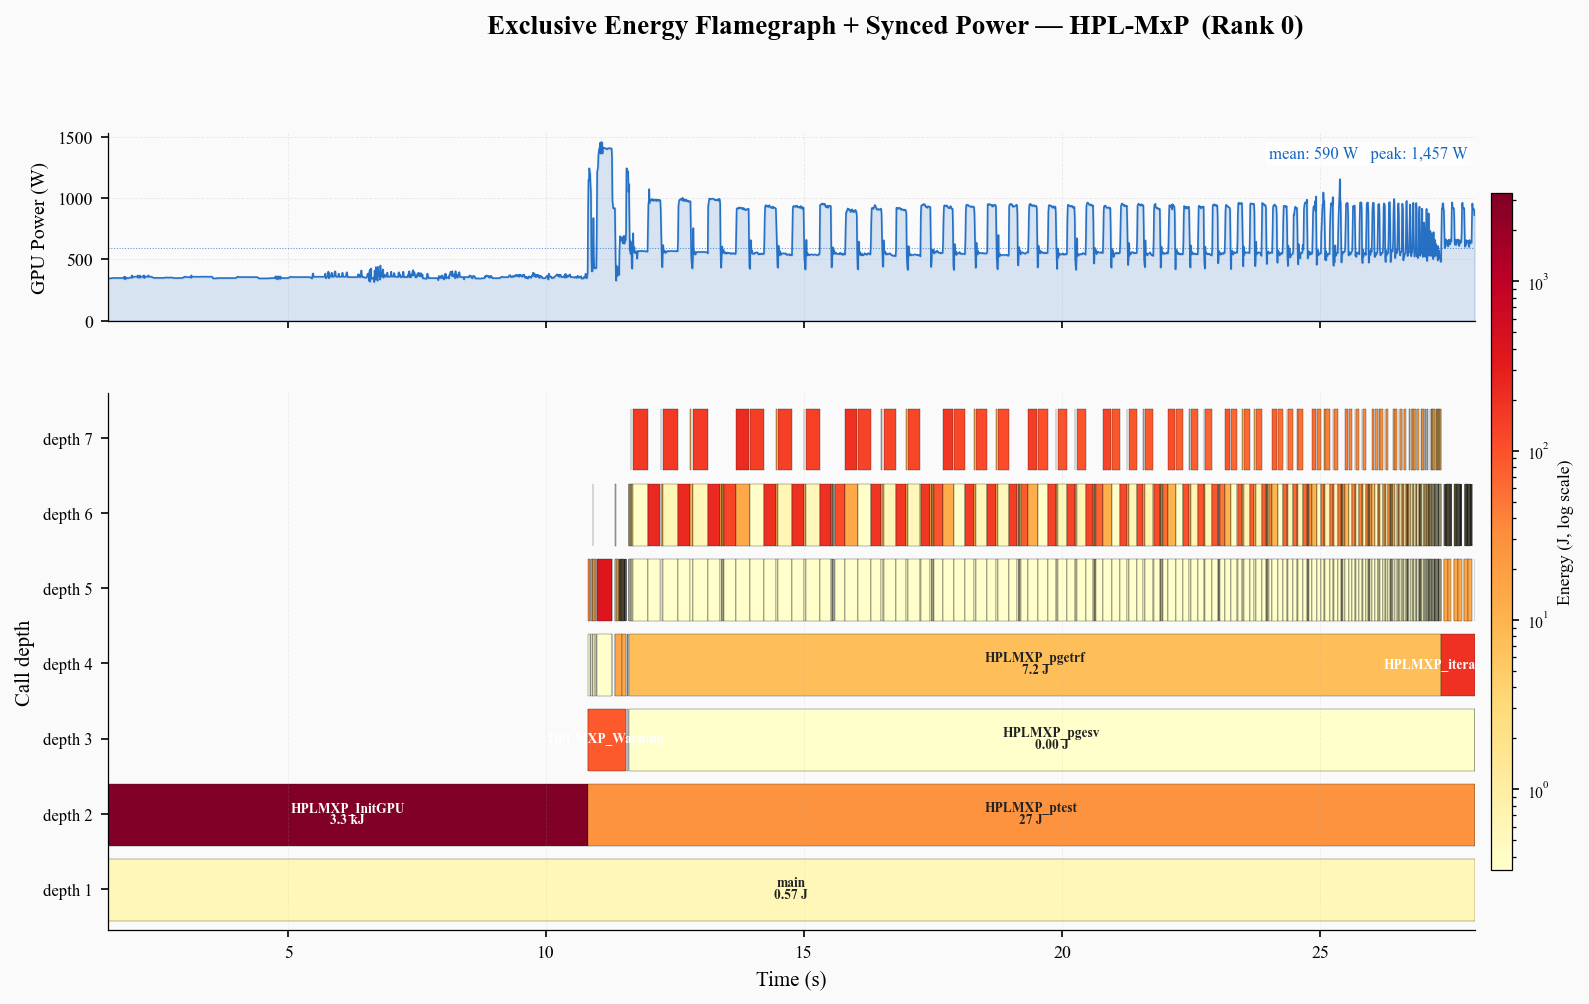

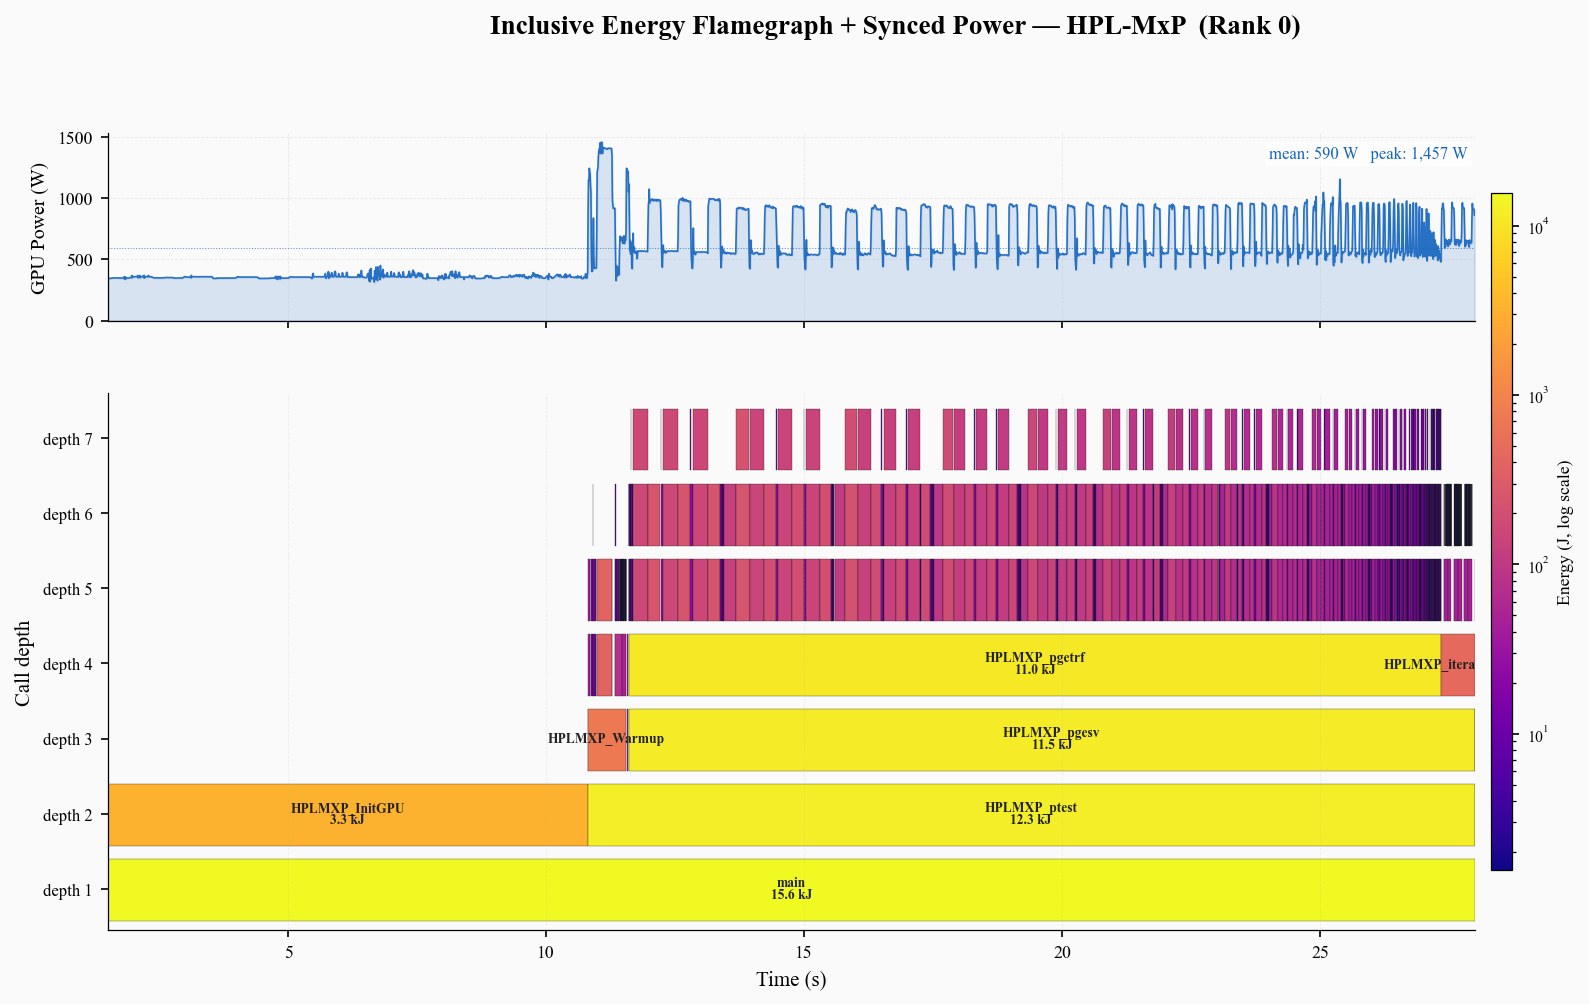

LSMS: 1,540 bars  ·  power samples: 6,457  ·  window [1.51, 53.17] s


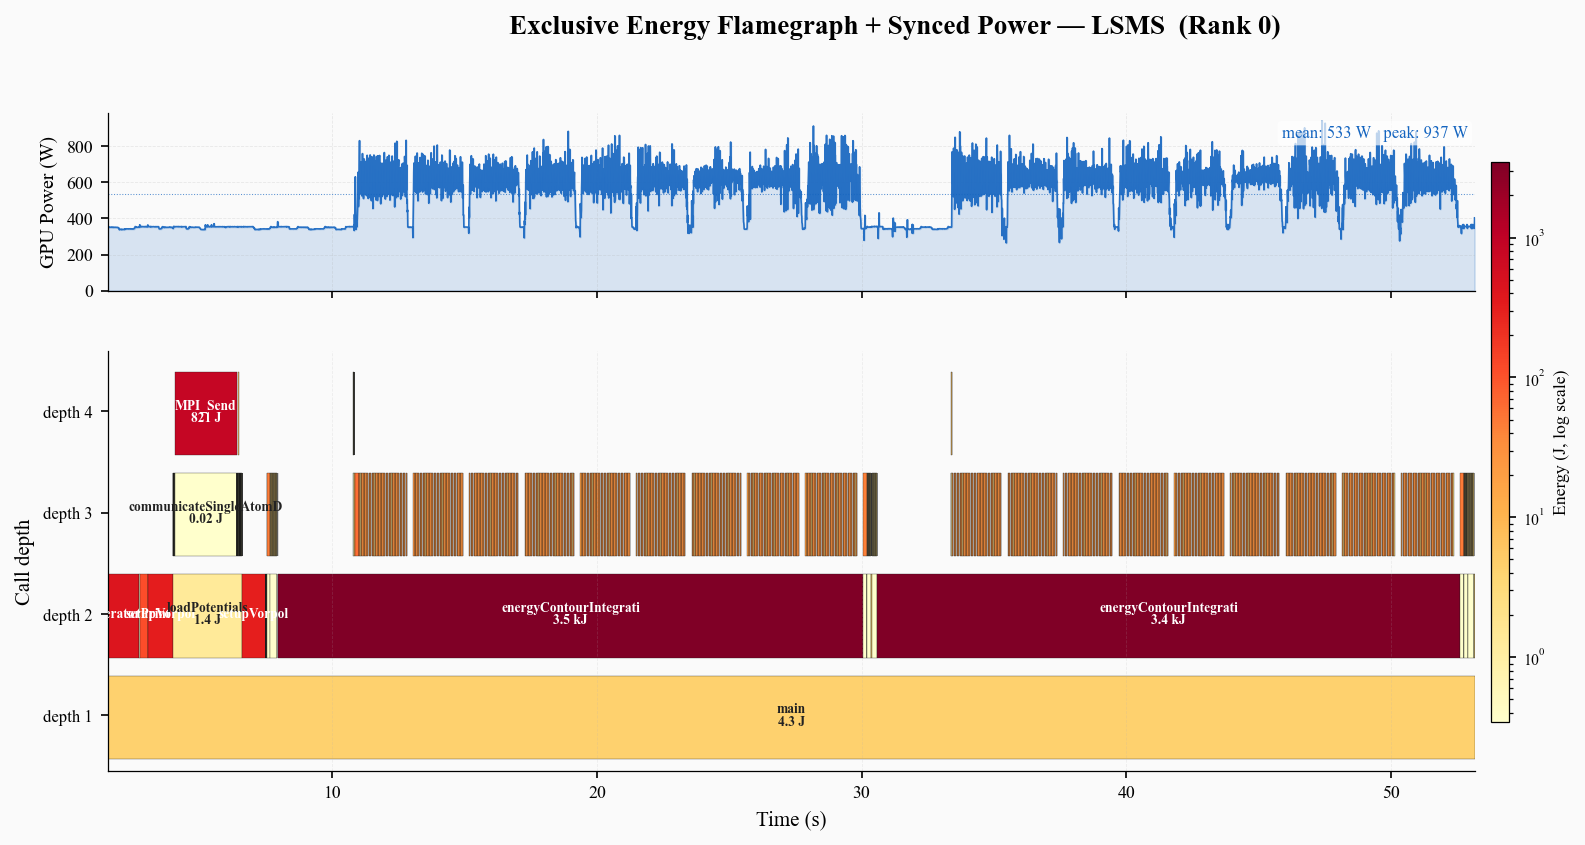

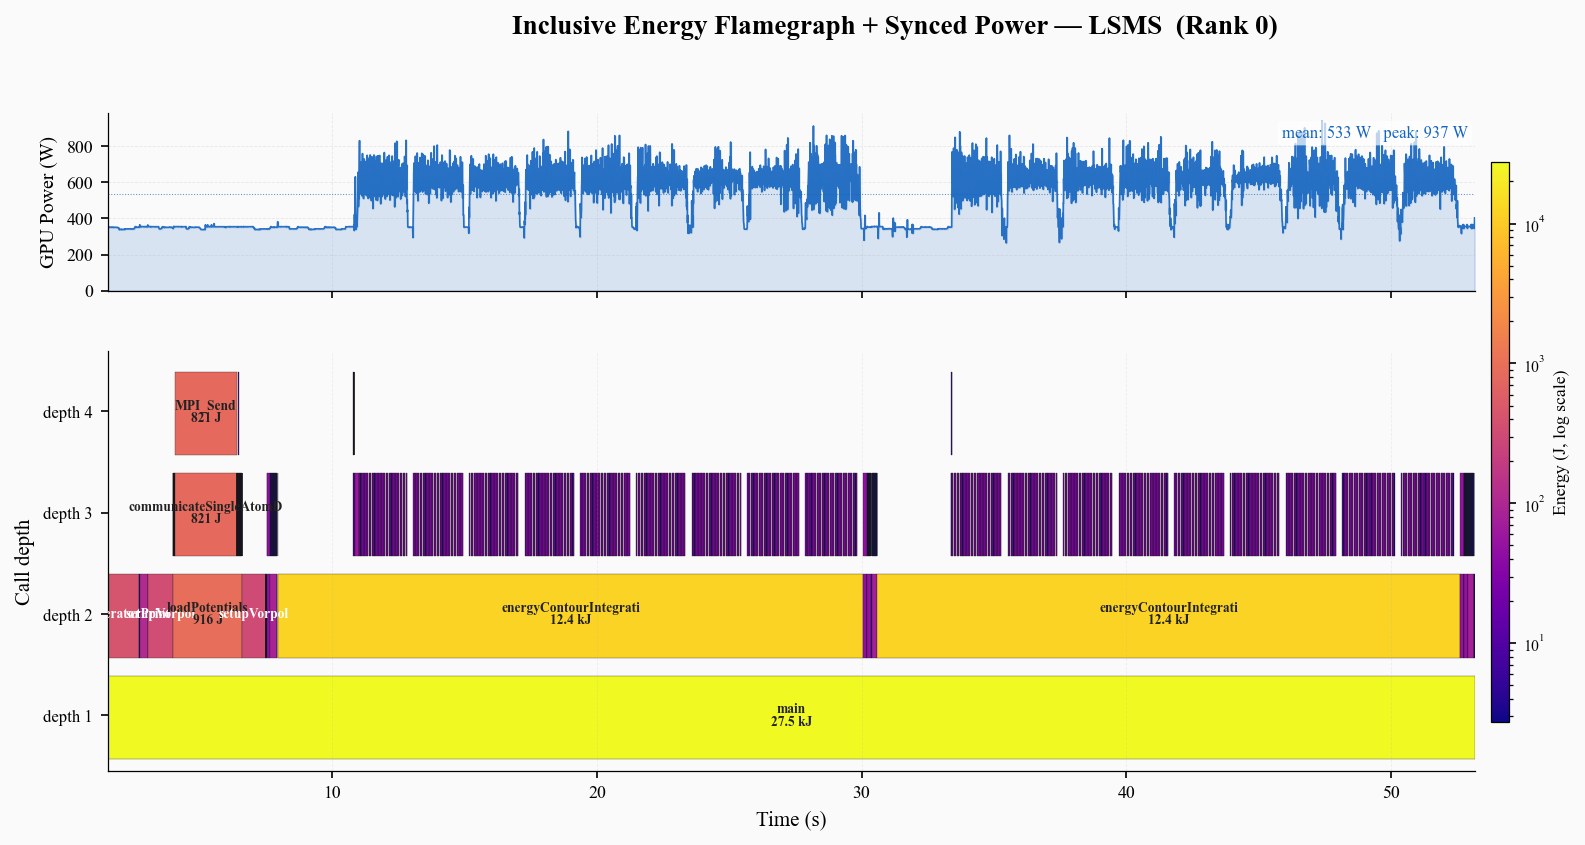

QMCPACK: 7,639 bars  ·  power samples: 11,250  ·  window [1.50, 91.50] s


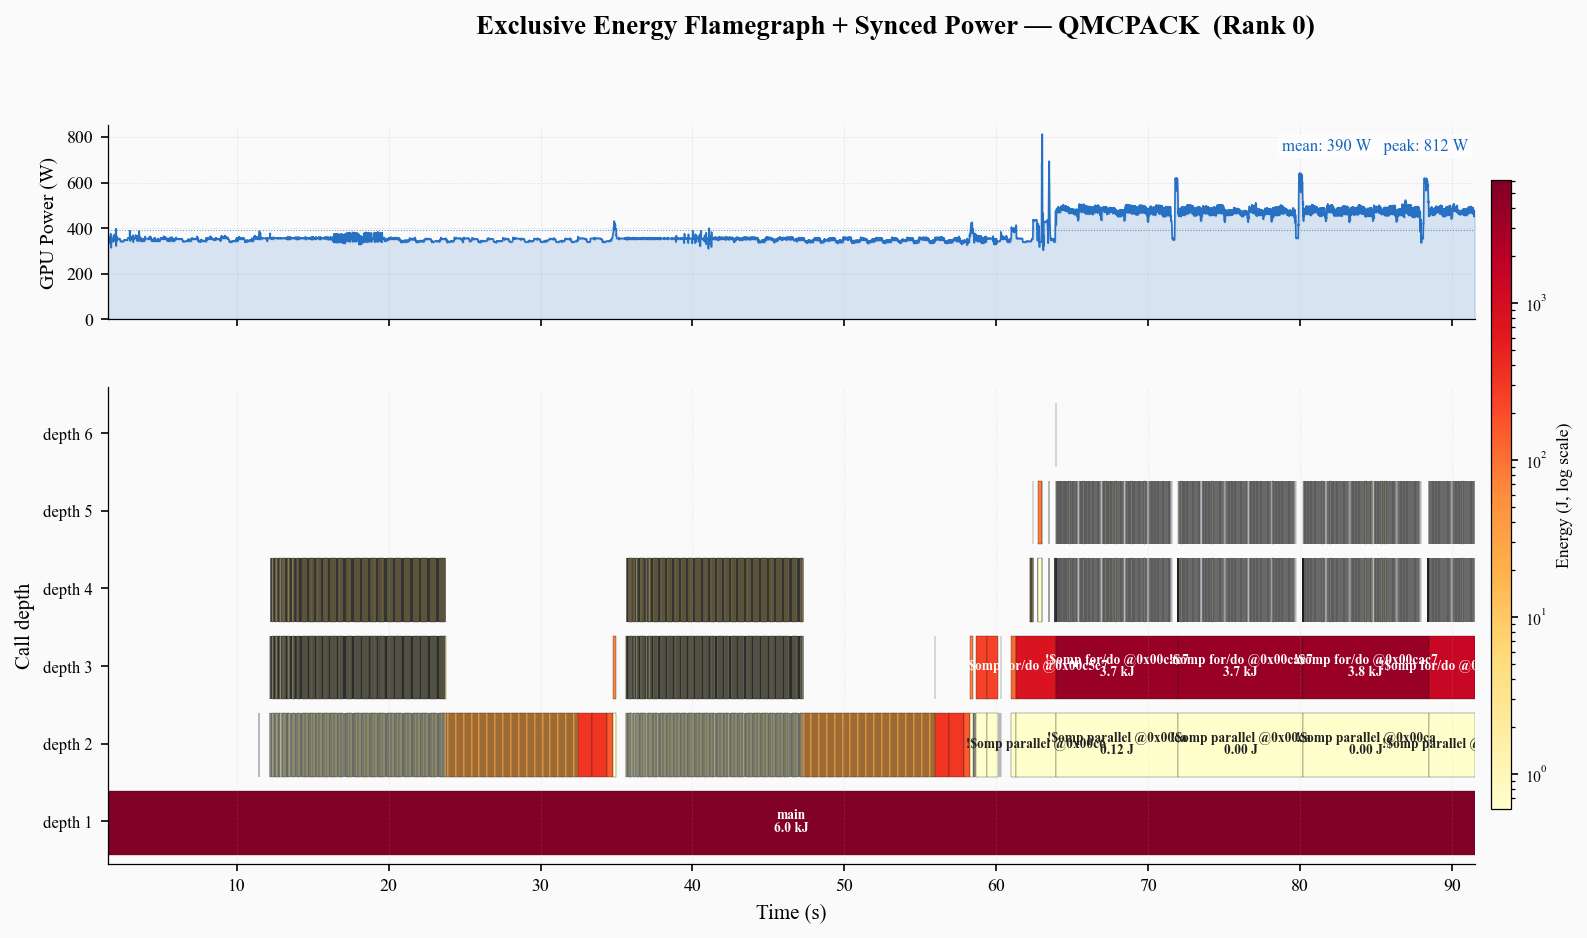

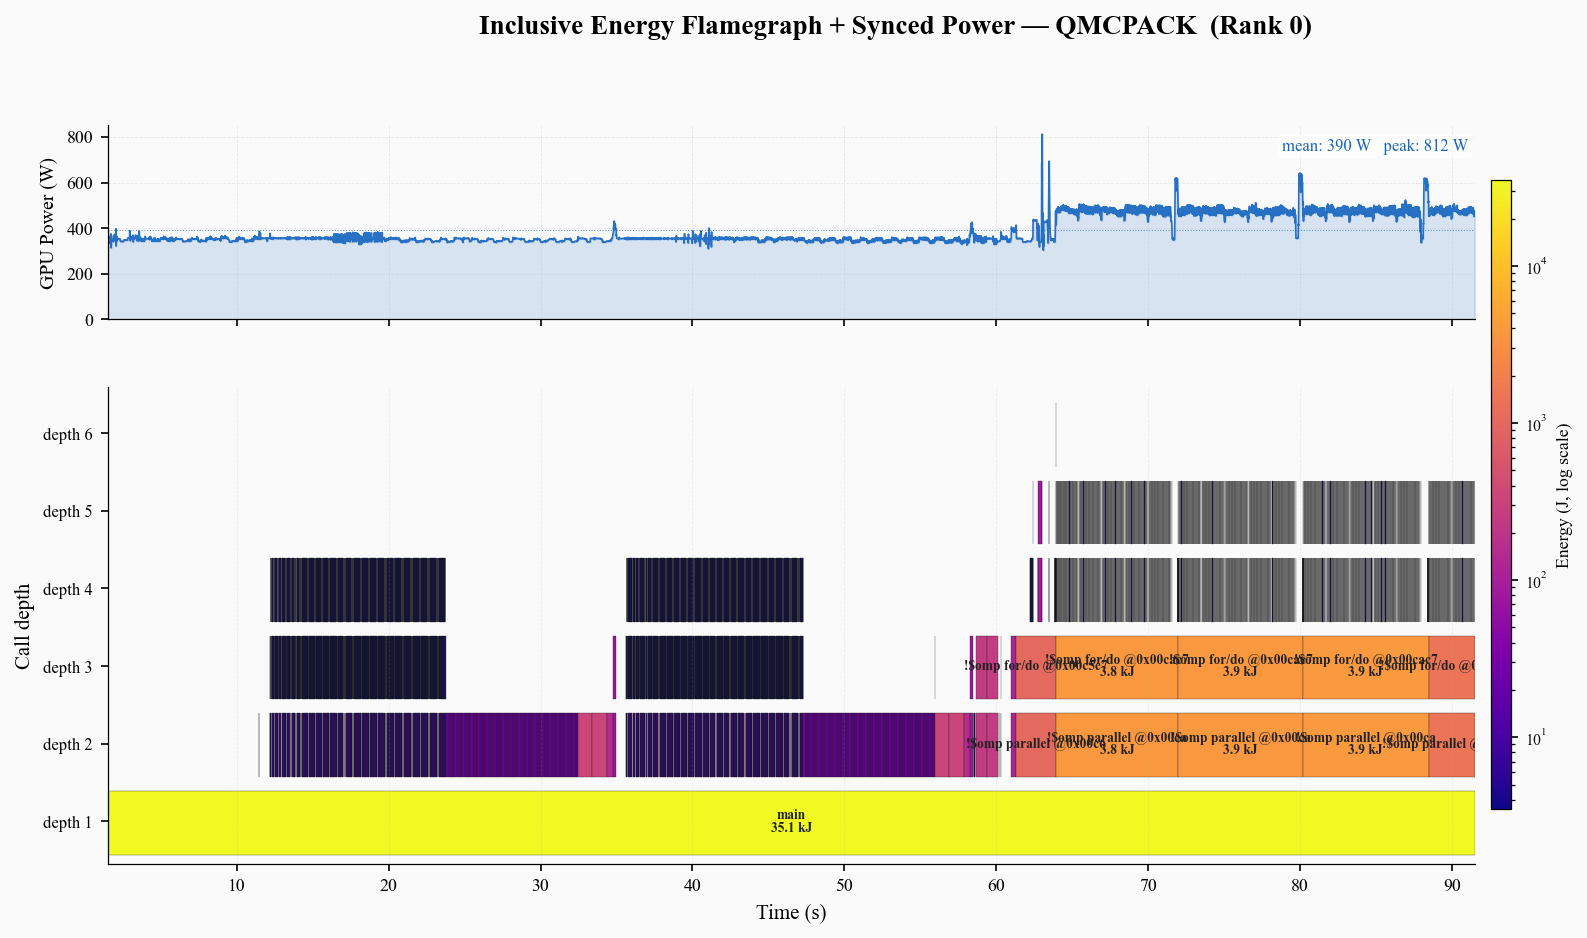

In [7]:
def draw_flamegraph_with_power(df: pd.DataFrame,
                                energy_col: str,
                                power_t, power_v,
                                title: str,
                                cmap_name: str = 'YlOrRd',
                                save_path: str | None = None,
                                label_min_frac: float = 0.015):
    """Two-panel: GPU power curve on top, energy-colored flamegraph below,
    sharing the x-axis so power draw can be read off against the callgraph."""
    if df is None or df.empty:
        print(f"  [skip] no data for {title}"); return

    energies = df[energy_col].values
    norm     = _flame_color_norm(energies)
    cmap     = plt.get_cmap(cmap_name)

    max_d   = int(df['Depth'].max())
    t_start = df['Start Time'].min()
    t_end   = df['End Time'].max()
    span    = t_end - t_start

    flame_h = max(3.5, max_d * 0.5 + 1.2)
    fig, (ax_p, ax_f) = plt.subplots(
        2, 1,
        figsize=(14, flame_h + 2.2),
        facecolor=BG,
        gridspec_kw={'height_ratios': [1.1, max(2.6, max_d * 0.45)]},
        sharex=True,
    )
    ax_p.set_facecolor(BG)
    ax_f.set_facecolor(BG)

    if power_t is not None and len(power_t) > 0:
        ax_p.plot(power_t, power_v, lw=0.8, color='#1565C0', alpha=0.9)
        ax_p.fill_between(power_t, power_v, alpha=0.15, color='#1565C0')
        ax_p.set_ylabel('GPU Power (W)', fontsize=9.5)
        ax_p.set_ylim(0)
        ax_p.grid(alpha=0.25, linestyle='--')

        mean_p = float(np.mean(power_v))
        peak_p = float(np.max(power_v))
        ax_p.axhline(mean_p, color='#1565C0', lw=0.5, ls=':', alpha=0.7)
        ax_p.text(0.995, 0.93,
                  f"mean: {mean_p:,.0f} W   peak: {peak_p:,.0f} W",
                  transform=ax_p.transAxes, ha='right', va='top',
                  fontsize=8, color='#1565C0',
                  bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                            edgecolor='none', alpha=0.7))

    for _, row in df.iterrows():
        e = row[energy_col]
        color = cmap(norm(e)) if e > 0 else cmap(0.0)
        rect  = mpatches.FancyBboxPatch(
            (row['Start Time'], row['Depth'] - 0.43),
            max(row['Duration'], 0.0),
            0.82,
            boxstyle='square,pad=0',
            facecolor=color, edgecolor='#1a1a1a', linewidth=0.15,
        )
        ax_f.add_patch(rect)

        if span > 0 and row['Duration'] / span > label_min_frac:
            brightness = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
            txt_color  = 'white' if brightness < 0.55 else '#222'
            label = row['Short'][:22]
            if row['Duration'] / span > 0.04:
                label = f"{label}\n{_format_joules(e)}"
            ax_f.text(row['Start Time'] + row['Duration'] * 0.5,
                      row['Depth'],
                      label,
                      ha='center', va='center',
                      fontsize=6.5, color=txt_color, fontweight='bold',
                      clip_on=True, linespacing=0.95)

    ax_f.set_xlim(t_start, t_end)
    ax_f.set_ylim(0.45, max_d + 0.6)
    ax_f.set_yticks(range(1, max_d + 1))
    ax_f.set_yticklabels([f'depth {d}' for d in range(1, max_d + 1)], fontsize=8)
    ax_f.set_xlabel('Time (s)', fontsize=10)
    ax_f.set_ylabel('Call depth', fontsize=10)
    ax_f.grid(axis='x', alpha=0.18, linestyle='--')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=[ax_p, ax_f], shrink=0.85, pad=0.01,
                      aspect=32, location='right')
    cb.set_label('Energy (J, log scale)' if isinstance(norm, mcolors.LogNorm)
                 else 'Energy (J)', fontsize=8.5)
    cb.ax.tick_params(labelsize=7.5)

    fig.suptitle(title, fontweight='bold', y=0.995)
    if save_path:
        fig.savefig(save_path, facecolor=BG, bbox_inches='tight')
    plt.show()


# ── Run for each benchmark.  All heavy work is cached: re-running this cell
# after the Figs 3/4 cell has already executed reuses both the flame DataFrame
# and the differentiated power series, so only the matplotlib drawing is paid.
for bench_name, trial_path in BENCHMARKS.items():
    cg_path = trial_path / 'MPI Rank 0_Master_thread_callgraph.csv'
    m_path  = trial_path / 'MPI Rank 0_metrics.csv'
    if not cg_path.exists() or not m_path.exists():
        print(f"  [skip] {bench_name}: missing rank-0 files"); continue

    max_depth, min_dur_s, t_window = pick_flame_params(cg_path)
    flame_df = get_flame_data(cg_path, m_path, max_depth, min_dur_s, t_window)
    if flame_df is None or flame_df.empty:
        print(f"  [skip] {bench_name}: no data"); continue

    power_t, power_v = get_combined_power(m_path)
    if power_t is not None:
        mask    = (power_t >= t_window[0]) & (power_t <= t_window[1])
        power_t = power_t[mask]
        power_v = power_v[mask]

    print(f"{bench_name}: {len(flame_df):,} bars  ·  power samples: "
          f"{0 if power_t is None else len(power_t):,}  ·  window "
          f"[{t_window[0]:.2f}, {t_window[1]:.2f}] s")

    draw_flamegraph_with_power(
        flame_df, 'ExclusiveE', power_t, power_v,
        title=f'Exclusive Energy Flamegraph + Synced Power — {bench_name}  (Rank 0)',
        cmap_name='YlOrRd',
        save_path=f'fig5_exclusive_flame_power_{bench_name}.pdf',
    )

    draw_flamegraph_with_power(
        flame_df, 'InclusiveE', power_t, power_v,
        title=f'Inclusive Energy Flamegraph + Synced Power — {bench_name}  (Rank 0)',
        cmap_name='plasma',
        save_path=f'fig6_inclusive_flame_power_{bench_name}.pdf',
    )


## Figure 3: Library Energy Breakdown

For each discovered benchmark, show how GPU energy is split across compute libraries.  
Results update automatically when new benchmark data is placed in `app-traces/`.

In [8]:
# Build `bench_energy` from the cached attribution.  If the heatmap cell
# above already ran for these trials, this is essentially free; otherwise
# this is the one place attribution actually runs.
bench_energy = {}
for bench_name, trial_path in BENCHMARKS.items():
    print(f"Loading {bench_name}...")
    attr = get_attribution(trial_path)
    if attr is None or len(attr) == 0:
        print(f"  [skip] {bench_name}: no attribution data")
        continue
    # `Bench` tag is the only thing the breakdown cells specifically need
    # beyond the cached attribution columns.
    bench_energy[bench_name] = attr.assign(Bench=bench_name)
    print(f"  {len(attr):,} attributed rows")

if not bench_energy:
    print("No attribution data available.")


Loading HPG-MxP-Full...
  4,481,620 attributed rows
Loading HPL...
  2,809,798 attributed rows
Loading HPL-MxP...
  237,587 attributed rows
Loading LSMS...
  33,410 attributed rows
Loading QMCPACK...
  11,669,254 attributed rows


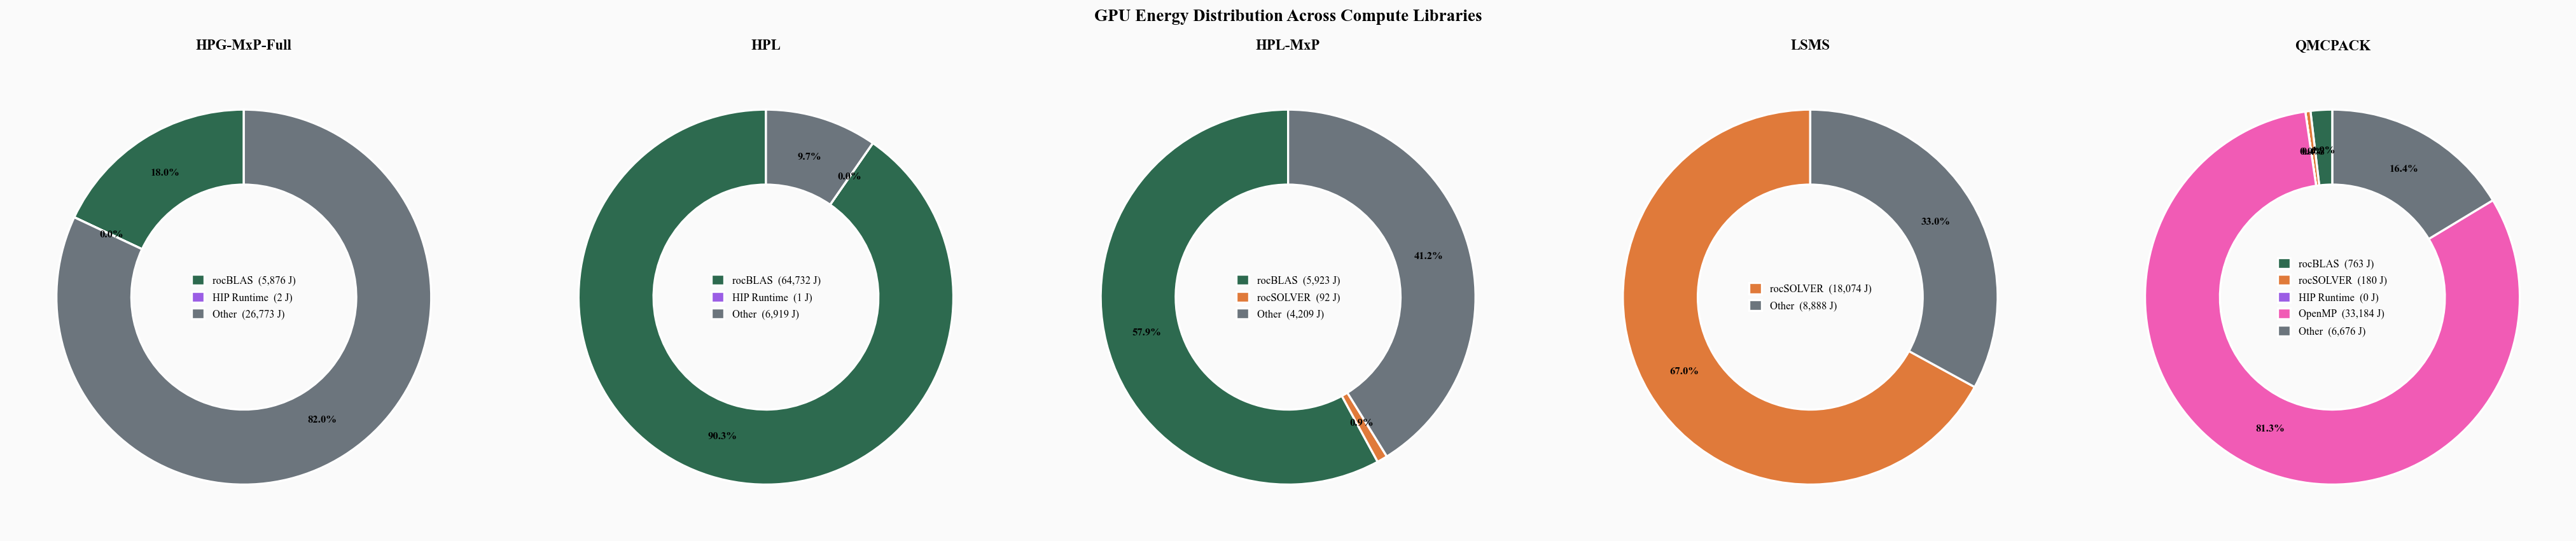

In [9]:
if bench_energy:
    n_bench = len(bench_energy)
    fig, axes = plt.subplots(1, n_bench, figsize=(5.5 * n_bench, 5.5), facecolor=BG)
    if n_bench == 1:
        axes = [axes]

    for ax, (bench_name, attr) in zip(axes, bench_energy.items()):
        ax.set_facecolor(BG)

        # Re-classify on the fly so changes to classify() take effect without
        # having to rerun the slow attribution cell above.
        attr = attr.assign(Library=attr['Name'].apply(classify))

        # Compute energy share by library (exclude MPI idle)
        compute = attr[attr['Library'] != 'MPI']
        lib_e   = compute.groupby('Library')['Value'].sum()
        lib_e   = lib_e.reindex([c for c in LIB_ORDER if c in lib_e.index])
        colors  = [PALETTE[c] for c in lib_e.index]

        wedges, _, autotexts = ax.pie(
            lib_e.values, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.78,
            wedgeprops=dict(width=0.40, edgecolor='white', linewidth=1.6))
        for t in autotexts:
            t.set_fontsize(8); t.set_fontweight('bold')

        legend_labels = [f"{lib}  ({lib_e[lib]:,.0f} J)" for lib in lib_e.index]
        ax.legend(wedges, legend_labels, loc='center', fontsize=8,
                  frameon=False, handlelength=1.2, handleheight=1.2)
        ax.set_title(bench_name, fontsize=11, fontweight='bold', pad=10)

    fig.suptitle('GPU Energy Distribution Across Compute Libraries',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig('fig3_library_donuts.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()


## Figure 4: Top Functions by Energy

Horizontal bar chart of the top-20 most energy-intensive functions, one panel per benchmark.

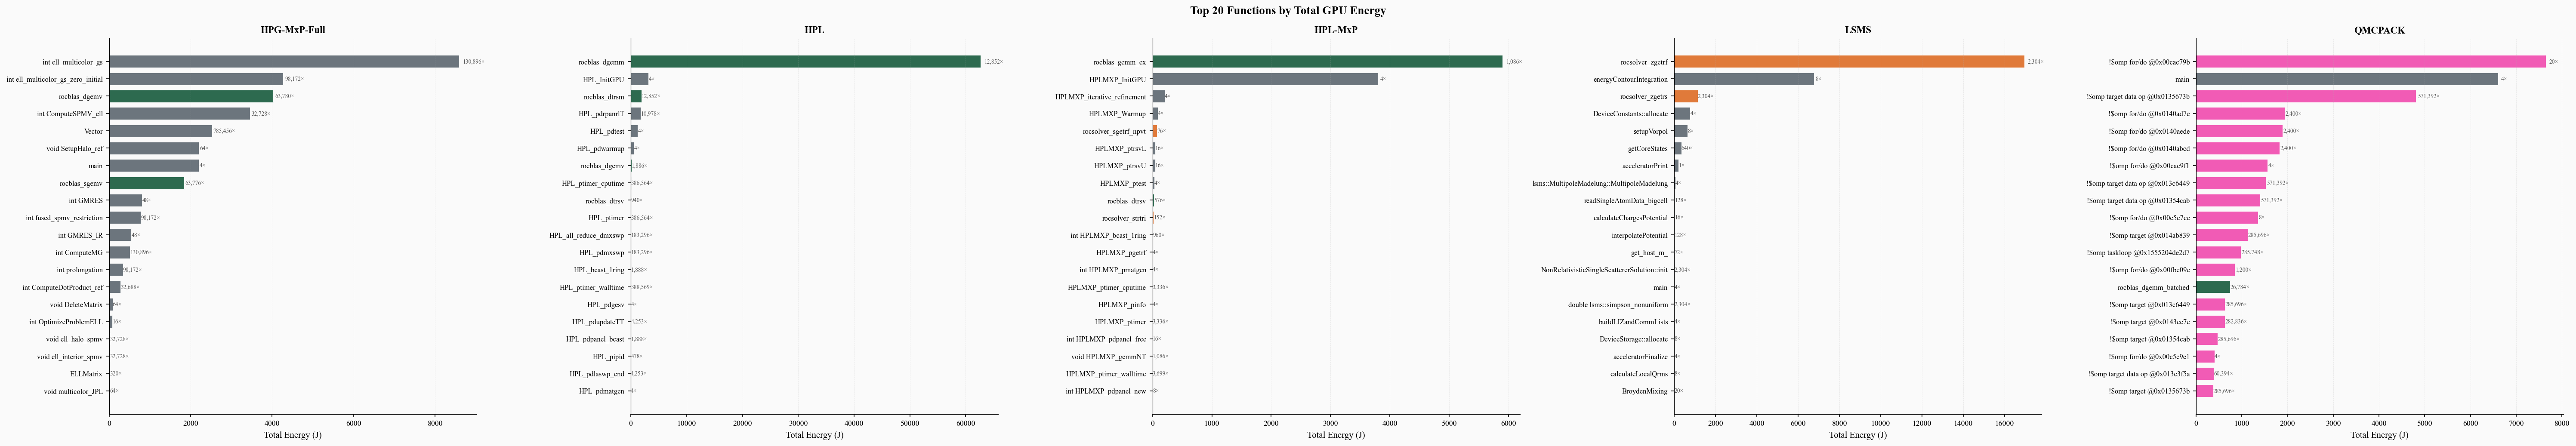

In [10]:
if bench_energy:
    n_bench = len(bench_energy)
    TOP_N = 20

    fig, axes = plt.subplots(1, n_bench,
                              figsize=(8 * n_bench, 7),
                              facecolor=BG)
    if n_bench == 1:
        axes = [axes]

    for ax, (bench_name, attr) in zip(axes, bench_energy.items()):
        ax.set_facecolor(BG)
        # Re-classify on the fly so changes to classify() take effect without
        # having to rerun the slow attribution cell above.
        attr = attr.assign(Library=attr['Name'].apply(classify))
        compute = attr[attr['Library'] != 'MPI'].copy()
        compute['ShortName'] = compute['Name'].apply(short_name)
        func_e  = (compute.groupby(['ShortName', 'Library'])
                   .agg(total_energy=('Value', 'sum'), count=('Value', 'size'))
                   .reset_index()
                   .sort_values('total_energy', ascending=False)
                   .head(TOP_N))

        colors = [PALETTE.get(row['Library'], '#6c757d')
                  for _, row in func_e.iterrows()]
        ax.barh(range(len(func_e)), func_e['total_energy'].values,
                color=colors, edgecolor='white', linewidth=0.4, height=0.72)
        ax.set_yticks(range(len(func_e)))
        ax.set_yticklabels(func_e['ShortName'].values, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Total Energy (J)')
        ax.set_title(bench_name, fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.25, linestyle='--')

        # Call count annotations
        for i, (_, row) in enumerate(func_e.iterrows()):
            ax.text(row['total_energy'] * 1.01, i,
                    f"{row['count']:,}×", va='center', fontsize=6.5, color='#555')

    fig.suptitle(f'Top {TOP_N} Functions by Total GPU Energy',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig('fig4_top_functions.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()
